# Factorial Experiment — Results Visualizations

Reads the aggregated outputs from `dl_08_aggregate_factorial.py`
(`Models/factorial_results/analysis/`) plus the per-cell SHAP JSONs written by
`dl_09_shap_factorial.py`, and renders the headline figures:

1. **Overall metrics** — accuracy, macro-F1, mean-IoU per config (± seed sd)
2. **Per-class metrics** — recall / F1 / IoU per class, per config (+ heatmaps)
3. **Confusion matrices** — seed-mean, raw counts and row-normalized (%)
4. **SHAP feature importance** — per model, averaged across seeds (overall + per-class)
5. **Extras** — contrasts forest plot (the actual scientific story), seed-variability
   strips, and the SHAP-reliance vs ablation-gain pairing

Everything is read-only and tolerant of a partial tree, so it is safe to re-run
while more cells are still finishing. Configure paths in the **Setup** cell.


In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# seaborn drives every heatmap / confusion matrix. Self-heal if the active
# kernel doesn't have it (this repo has several Python envs floating around).
try:
    import seaborn as sns
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seaborn"])
    import seaborn as sns
sns.set_style("whitegrid")

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.3,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

# --- Experiment version + classification mode selectors ----------------------
# EXP_VERSION suffixes every results root (EXECUTION.md §11): "" = base factorial
# (Models/factorial_results, results_patchcurve, ...); "v2" -> the _v2 roots.
# MODE picks the classification axis. v2 nests a <mode> level under each results
# root (factorial_results_v2/<mode>/...); v1 has no such level. Both read from
# the env so the notebook can be pointed at a version/mode without editing code.
EXP_VERSION = os.environ.get("EXP_VERSION", "v3")   # "" = base; "v2", "v3", ...
MODE        = os.environ.get("MODE", "multiclass")  # "multiclass" | "binary"
_SUFFIX = f"_{EXP_VERSION}" if EXP_VERSION else ""

def find_models_dir() -> Path:
    """Locate the Models/ dir holding factorial_results{_SUFFIX}, cwd-agnostic."""
    here = Path.cwd()
    for base in [here, *here.parents]:
        cand = base / "Models"
        if (cand / f"factorial_results{_SUFFIX}").is_dir():
            return cand
    cand = Path("/ibstorage/anthony/NYS_Wetlands_DL/Models")
    if (cand / f"factorial_results{_SUFFIX}").is_dir():
        return cand
    raise FileNotFoundError(f"Could not locate Models/factorial_results{_SUFFIX}")

MODELS_DIR = find_models_dir()
_FACT_ROOT = MODELS_DIR / f"factorial_results{_SUFFIX}"
# v2 inserts a <mode> level under each results root; v1 has none. Detect it so
# the same notebook drives both layouts. MODE_LEVEL is "" when there is no such
# level (v1), otherwise the resolved mode dir name.
MODE_LEVEL = MODE if (_FACT_ROOT / MODE).is_dir() else ""
RESULTS_DIR  = _FACT_ROOT / MODE_LEVEL if MODE_LEVEL else _FACT_ROOT
ANALYSIS_DIR = RESULTS_DIR / "analysis"
FIG_DIR = ANALYSIS_DIR / "figures"      # PNGs are saved here for the write-up
FIG_DIR.mkdir(exist_ok=True, parents=True)

def with_mode(p: Path) -> Path:
    """Append the resolved <mode> level to a sibling results root (no-op on v1)."""
    return p / MODE_LEVEL if MODE_LEVEL else p

print("version :", EXP_VERSION or "(base)")
print("mode    :", MODE_LEVEL or "(no mode level / v1)")
print("results :", RESULTS_DIR)
print("analysis:", ANALYSIS_DIR)
print("figures :", FIG_DIR)


def _scores(metrics: dict) -> dict:
    """Score block of a metrics.json, schema-agnostic. v2 (run_config.sh) nests
    scores under 'test_metrics'; v1 (dl_05) wrote them flat. Mirrors the unwrap
    in dl_08_aggregate_factorial.py so every raw metrics.json reader here agrees."""
    return metrics.get("test_metrics") or metrics


# --- Canonical ordering / labels (from dl_experiment_config, the source of truth) --
# Derive CONFIG_ORDER from the registry so a matrix change here needs no edit.
# Falls back to the hardcoded v2 order if the import is unavailable (e.g. a
# kernel without rasterio, which dl_experiment_config imports transitively).
_V2_CONFIG_ORDER = [
    "fld_nolidar_leafon", "fld_nolidar_leafoff",
    "fld_chmret_leafon",  "fld_chmret_leafoff",
    "nwi_chmret_leafoff", "nwiextra_chmret_leafoff",
    "nwifield_chmret_leafoff", "flddeg_chmret_leafoff",
]
try:
    _PIPE = MODELS_DIR.parent / "Python_Code_Analysis" / "DL_Pipeline_v2"
    if str(_PIPE) not in sys.path:
        sys.path.insert(0, str(_PIPE))
    from dl_experiment_config import CONFIGS as _CONFIGS
    CONFIG_ORDER = list(_CONFIGS.keys())
except Exception as e:
    print(f"[config order] using hardcoded v2 order (registry import failed: {e})")
    CONFIG_ORDER = _V2_CONFIG_ORDER

# Class axis depends on the mode: binary collapses EMW/FSW/SSW -> WET.
if MODE_LEVEL == "binary":
    CLASS_ORDER = ["WET", "UPL"]
else:
    CLASS_ORDER = ["EMW", "FSW", "SSW", "UPL"]
CLASS_FULL = {"EMW": "Emergent", "FSW": "Forested", "SSW": "Scrub-Shrub",
              "UPL": "Upland", "WET": "Wetland"}

# A stable color per config and per class (used across every figure).
_cfg_cmap = plt.get_cmap("tab10")
CONFIG_COLORS = {c: _cfg_cmap(i % 10) for i, c in enumerate(CONFIG_ORDER)}
CLASS_COLORS = {"EMW": "#2ca02c", "FSW": "#1f77b4", "SSW": "#ff7f0e",
                "UPL": "#8c564b", "WET": "#2c7fb8"}

def order_configs(seq):
    """Keep CONFIG_ORDER, drop configs absent from `seq`, append any extras."""
    present = [c for c in CONFIG_ORDER if c in set(seq)]
    extra = [c for c in seq if c not in CONFIG_ORDER]
    return present + sorted(set(extra))

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")


version : v3
mode    : multiclass
results : /local/workdir/ajs544/nys_wetlands/Models/factorial_results_v3/multiclass
analysis: /local/workdir/ajs544/nys_wetlands/Models/factorial_results_v3/multiclass/analysis
figures : /local/workdir/ajs544/nys_wetlands/Models/factorial_results_v3/multiclass/analysis/figures
[config order] using hardcoded v2 order (registry import failed: /local/workdir/ajs544/miniconda3/envs/geospatial-processing/lib/libsqlite3.so: cannot open shared object file: No such file or directory)


## Load the aggregated data

`factorial_long.csv` is the spine — one row per (config, seed, class). Cell-level
scalars (`overall_accuracy`, `macro_f1`, `mean_iou`) are repeated across that
cell's four class rows, so we `drop_duplicates("seed")` whenever we want one
value per (config, seed).

In [2]:
long = pd.read_csv(ANALYSIS_DIR / "factorial_long.csv")
summary = pd.read_csv(ANALYSIS_DIR / "factorial_summary.csv")
contrasts = pd.read_csv(ANALYSIS_DIR / "contrasts.csv")
coverage = pd.read_csv(ANALYSIS_DIR / "coverage.csv")

# Order config as an ordered categorical so every groupby/plot sorts the same.
present_cfgs = order_configs(long["config"].unique())
long["config"] = pd.Categorical(long["config"], categories=present_cfgs, ordered=True)

n_seeds = long.groupby("config", observed=True)["seed"].nunique()
print(f"Configs present : {len(present_cfgs)}")
print(f"Coverage        : {int(coverage['present'].sum())}/{len(coverage)} cells")
print("\nSeeds per config:")
print(n_seeds.to_string())

# Cell-level frame: one row per (config, seed) for the overall metrics.
cell = (long.drop_duplicates(["config", "seed"])
            .loc[:, ["config", "seed", "label", "lidar", "spectral", "featureset",
                     "overall_accuracy", "macro_f1", "macro_recall",
                     "macro_precision", "mean_iou", "in_channels"]]
            .reset_index(drop=True))
cell.head()


Configs present : 8
Coverage        : 40/40 cells

Seeds per config:
config
fld_nolidar_leafon         5
fld_nolidar_leafoff        5
fld_chmret_leafon          5
fld_chmret_leafoff         5
nwi_chmret_leafoff         5
nwiextra_chmret_leafoff    5
nwifield_chmret_leafoff    5
flddeg_chmret_leafoff      5


,config,seed,label,lidar,spectral,featureset,overall_accuracy,macro_f1,macro_recall,macro_precision,mean_iou,in_channels
0,fld_nolidar_leafon,0,fld,nolidar,leafon,nolidar_leafon,0.7063,0.5445,0.615425,0.53855,0.3978,21
1,fld_nolidar_leafon,1,fld,nolidar,leafon,nolidar_leafon,0.7912,0.5972,0.615575,0.58400,0.4542,21
2,fld_nolidar_leafon,2,fld,nolidar,leafon,nolidar_leafon,0.7844,0.5760,0.596950,0.57340,0.4424,21
3,fld_nolidar_leafon,3,fld,nolidar,leafon,nolidar_leafon,0.7893,0.5970,0.590750,0.60995,0.4550,21
4,fld_nolidar_leafon,4,fld,nolidar,leafon,nolidar_leafon,0.7847,0.5311,0.554400,0.52500,0.4041,21


## 1 · Overall model performance

Bars are the mean over seeds; error bars are ±1 sd across seeds (so they show the
seed-to-seed stability the factorial design is built to measure). The first six
configs are the field-label feature ablations; `nwi_*` and `flddeg_*` swap the
label source while holding the full feature set.

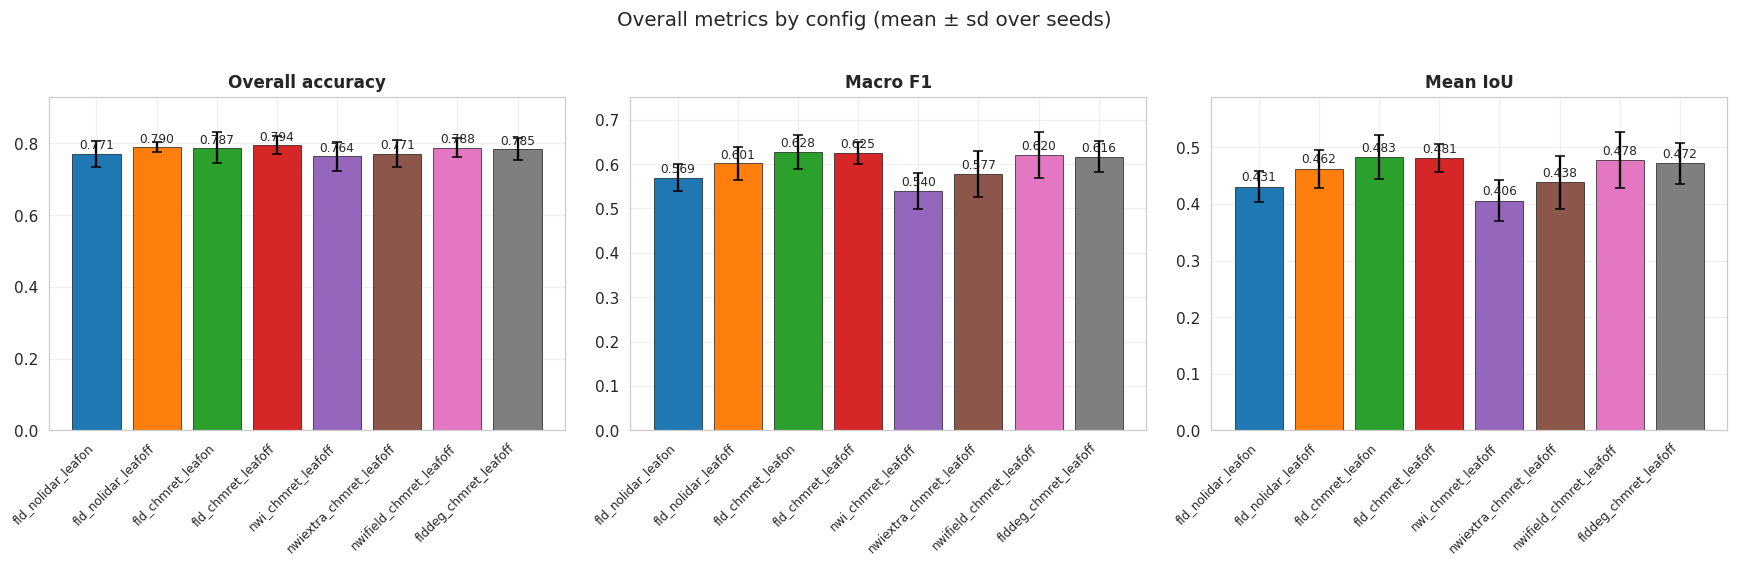

In [3]:
def mean_sd(frame, value, by="config"):
    g = frame.groupby(by, observed=True)[value]
    return g.mean(), g.std().fillna(0.0)

OVERALL_METRICS = [
    ("overall_accuracy", "Overall accuracy"),
    ("macro_f1",         "Macro F1"),
    ("mean_iou",         "Mean IoU"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, (col, title) in zip(axes, OVERALL_METRICS):
    m, s = mean_sd(cell, col)
    m = m.reindex(present_cfgs); s = s.reindex(present_cfgs)
    colors = [CONFIG_COLORS[c] for c in present_cfgs]
    ax.bar(range(len(m)), m.values, yerr=s.values, capsize=3,
           color=colors, edgecolor="black", linewidth=0.4)
    for i, v in enumerate(m.values):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(m)))
    ax.set_xticklabels(present_cfgs, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, (m + s).max() * 1.12))
fig.suptitle("Overall metrics by config (mean ± sd over seeds)", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, "01_overall_metrics")
plt.show()


## 2 · Per-class performance

For semantic segmentation the per-class story is what matters — the headline is
whether below-canopy features rescue **FSW** (forested wetland) recall without
costing **UPL**. Note: per-class *recall* is the producer's accuracy (diagonal of
the row-normalized confusion matrix); *precision* is the user's accuracy.

Two views: grouped bars (class on x, config as the group) for each metric, and a
config × class heatmap for a compact all-in-one read.

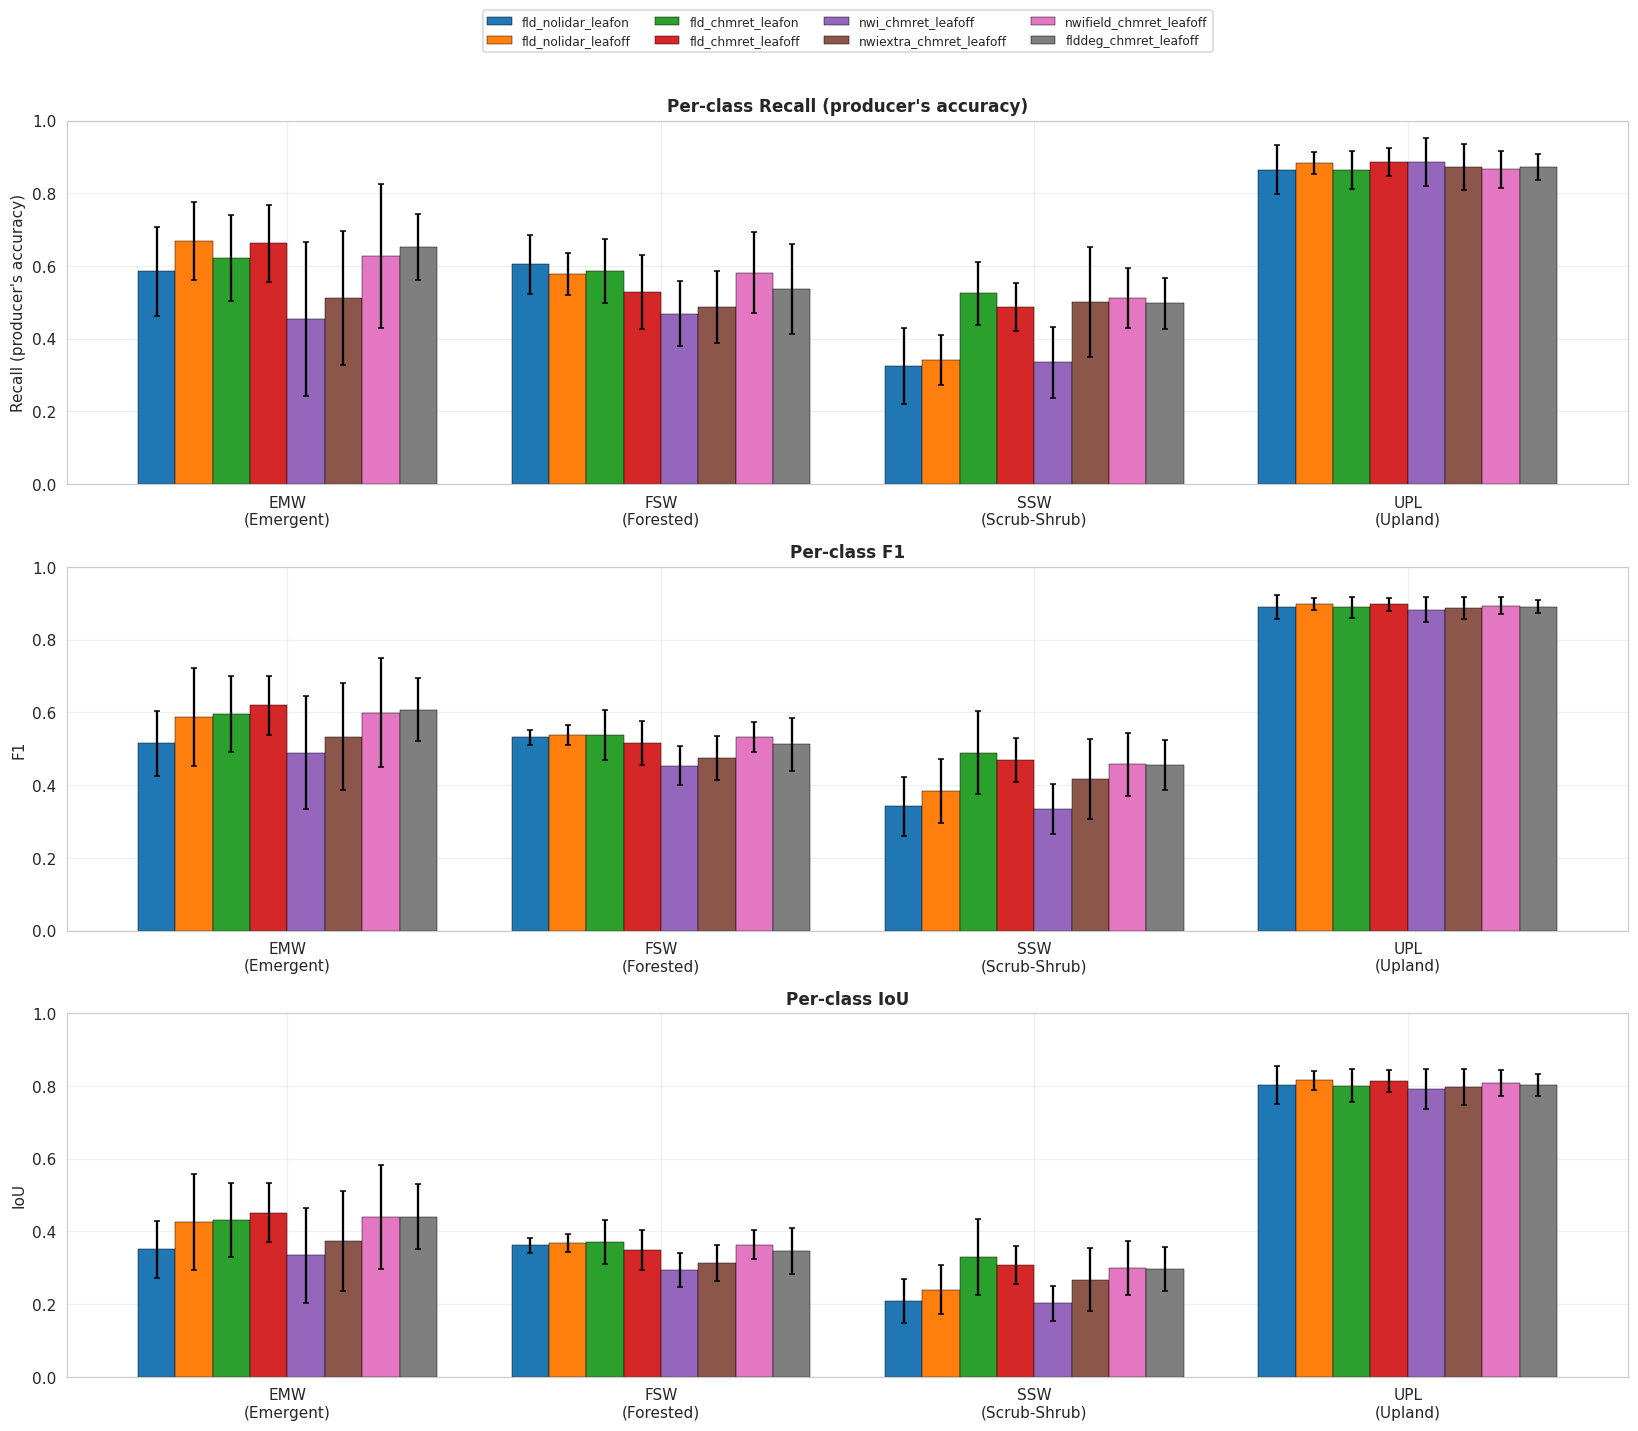

In [4]:
PER_CLASS_METRICS = [
    ("recall", "Recall (producer's accuracy)"),
    ("f1",     "F1"),
    ("iou",    "IoU"),
]

def per_class_table(metric):
    """(config x class) mean and sd over seeds for one per-class metric."""
    g = long.groupby(["config", "class"], observed=True)[metric]
    mean = g.mean().unstack("class").reindex(index=present_cfgs, columns=CLASS_ORDER)
    sd = g.std().unstack("class").reindex(index=present_cfgs, columns=CLASS_ORDER).fillna(0)
    return mean, sd

fig, axes = plt.subplots(3, 1, figsize=(15, 13))
x = np.arange(len(CLASS_ORDER))
w = 0.8 / max(len(present_cfgs), 1)
for ax, (metric, title) in zip(axes, PER_CLASS_METRICS):
    mean, sd = per_class_table(metric)
    for j, cfg in enumerate(present_cfgs):
        off = (j - (len(present_cfgs) - 1) / 2) * w
        ax.bar(x + off, mean.loc[cfg].values, w, yerr=sd.loc[cfg].values,
               capsize=2, label=cfg, color=CONFIG_COLORS[cfg],
               edgecolor="black", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n({CLASS_FULL[c]})" for c in CLASS_ORDER])
    ax.set_ylabel(title); ax.set_title(f"Per-class {title}")
    ax.set_ylim(0, 1.0)
axes[0].legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.32))
fig.tight_layout()
savefig(fig, "02_per_class_bars")
plt.show()


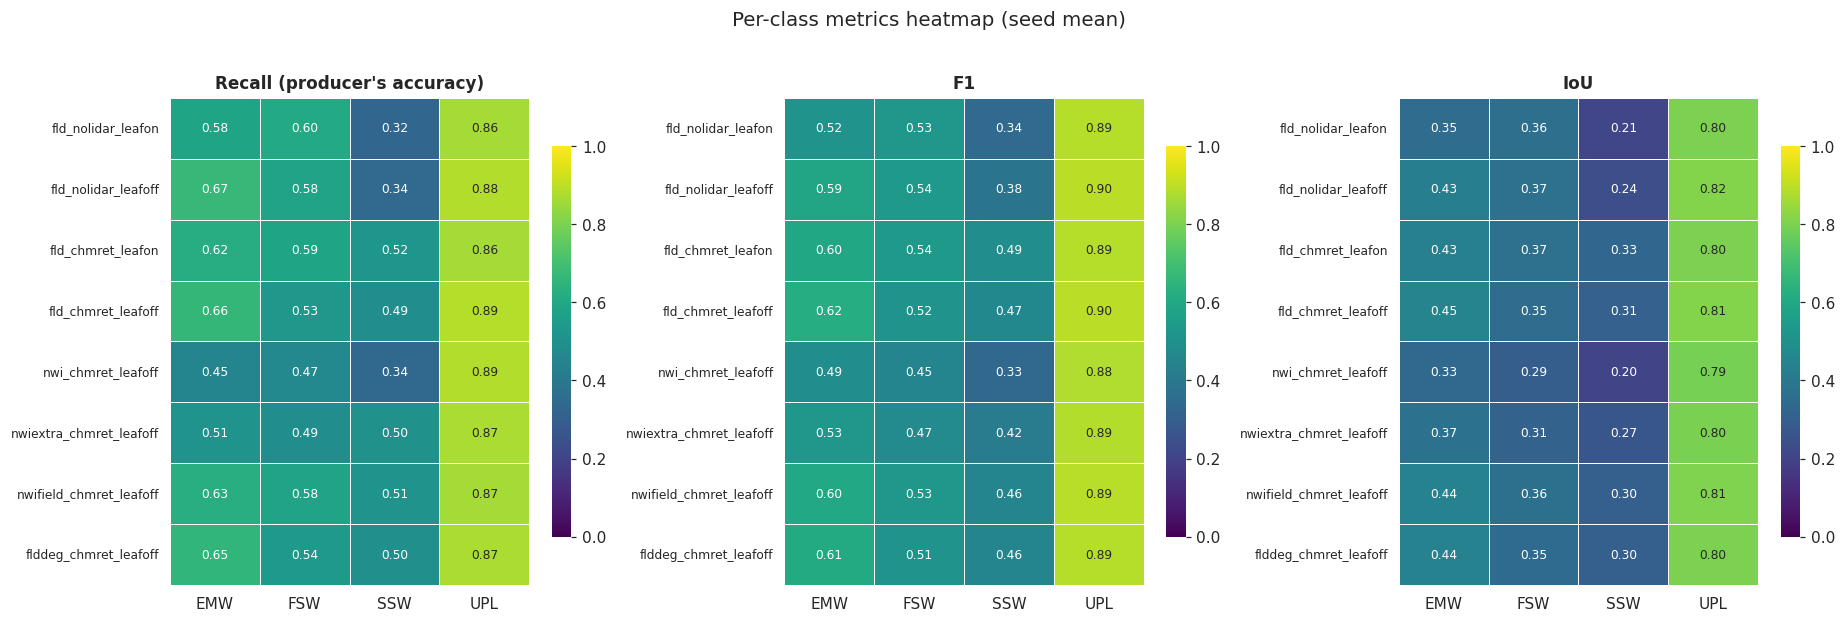

In [5]:
# Compact heatmaps: config (rows) x class (cols), one panel per metric.
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (metric, title) in zip(axes, PER_CLASS_METRICS):
    mean, _ = per_class_table(metric)
    sns.heatmap(mean, ax=ax, cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f",
                linewidths=0.5, linecolor="white", annot_kws={"fontsize": 8},
                cbar_kws={"shrink": 0.8})
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_yticklabels(present_cfgs, rotation=0, fontsize=8)
fig.suptitle("Per-class metrics heatmap (seed mean)", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, "02_per_class_heatmap")
plt.show()


## 3 · Confusion matrices (seed-mean)

From `confusion_mean/<config>.csv` (true rows × predicted columns, averaged over
seeds). **Raw counts** show absolute pixel volumes (dominated by UPL); **row-
normalized %** shows where each true class's pixels actually land — the diagonal
is per-class recall, off-diagonals are the confusion structure (the FSW↔UPL
below-canopy story lives here).

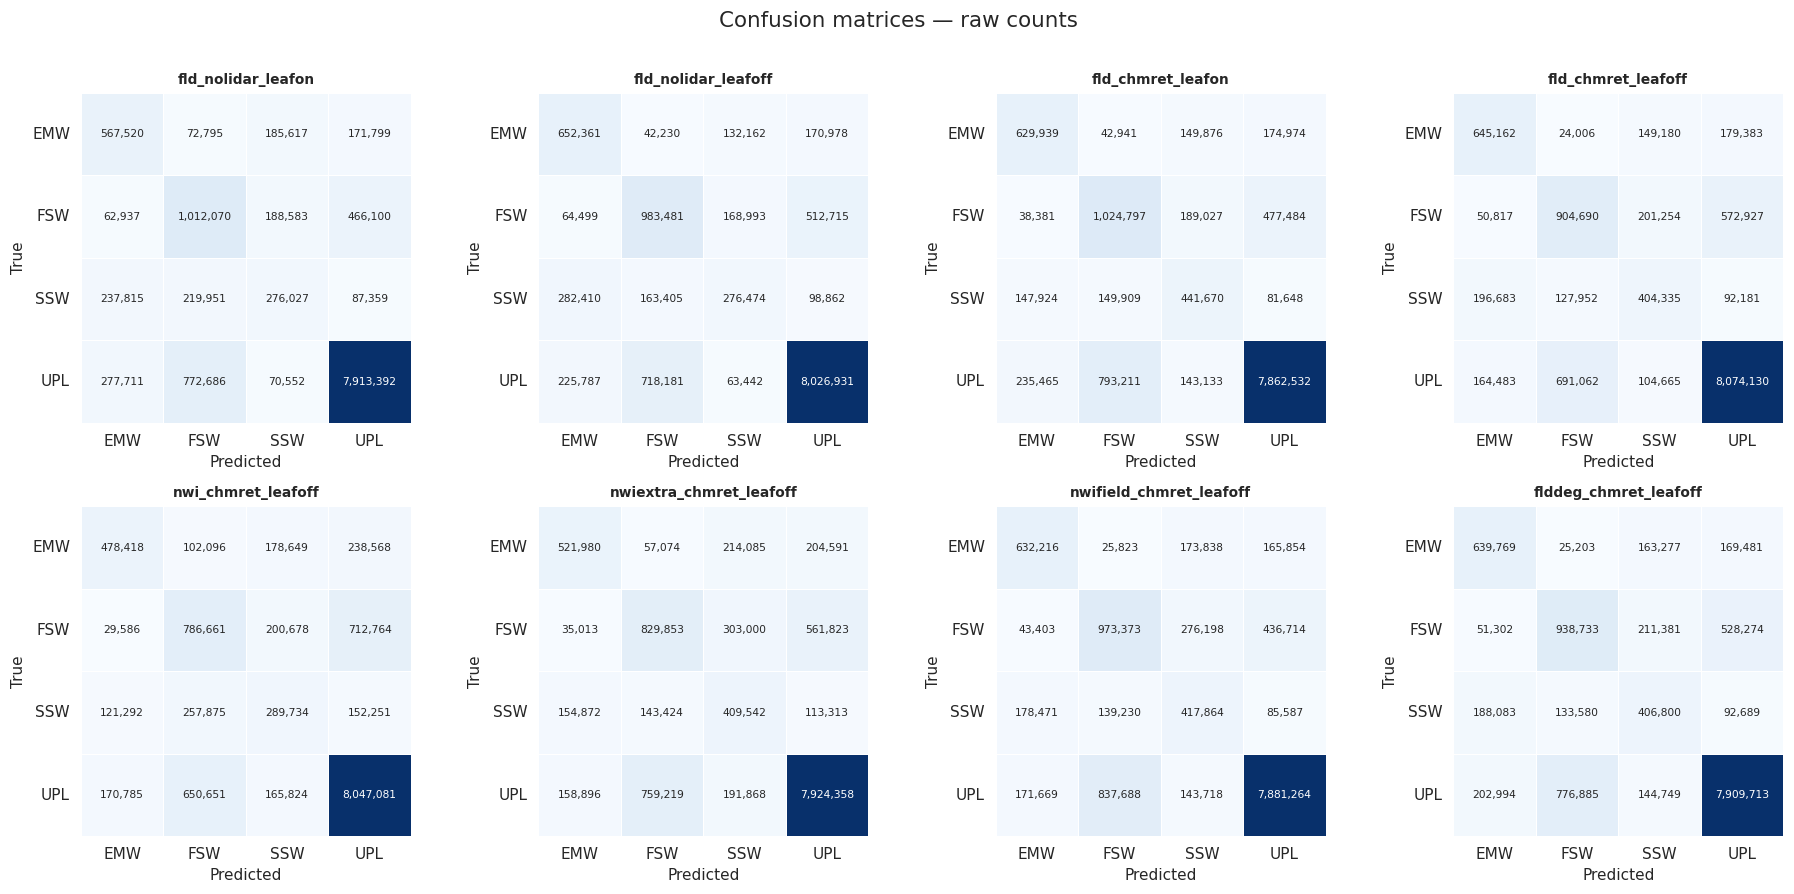

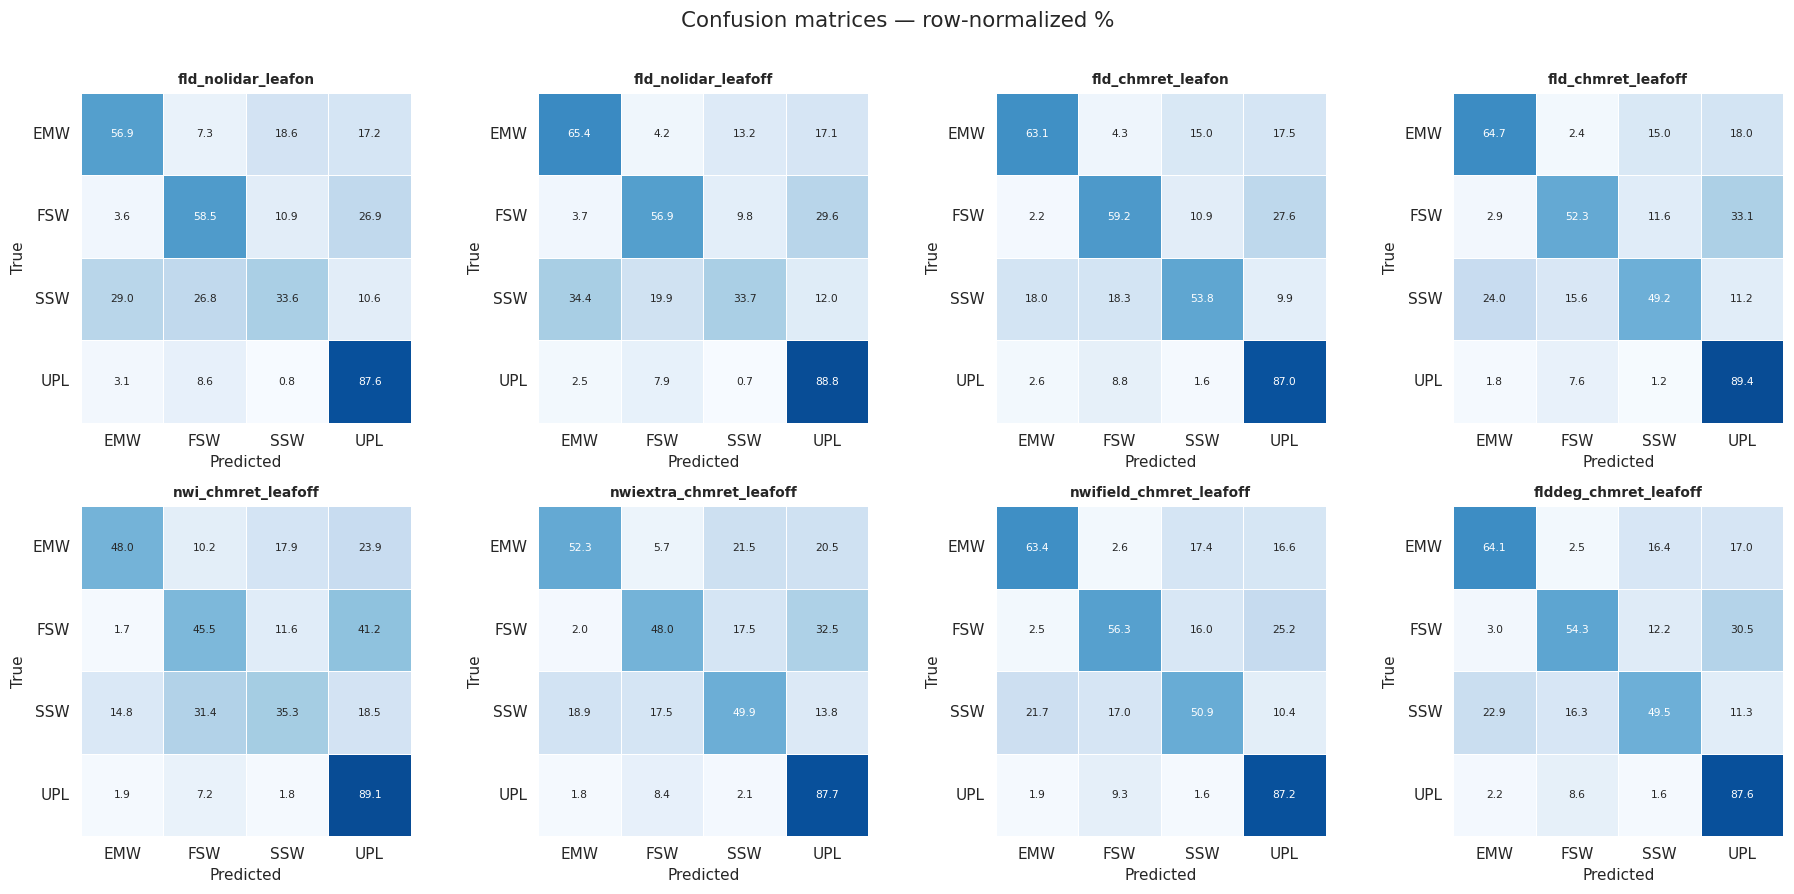

In [6]:
def load_confusion(cfg):
    f = ANALYSIS_DIR / "confusion_mean" / f"{cfg}.csv"
    if not f.exists():
        return None
    cm = pd.read_csv(f, index_col=0)
    return cm.reindex(index=CLASS_ORDER, columns=CLASS_ORDER)

def plot_cm(ax, cm, title, normalize=False):
    M = cm.astype(float)
    if normalize:
        M = M.div(M.sum(axis=1), axis=0) * 100.0
        fmt, vmax = ".1f", 100
    else:
        fmt, vmax = ",.0f", None
    sns.heatmap(M, ax=ax, cmap="Blues", vmin=0, vmax=vmax, annot=True, fmt=fmt,
                cbar=False, square=True, linewidths=0.5, linecolor="white",
                annot_kws={"fontsize": 7})
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title, fontsize=9)
    ax.set_yticklabels(CLASS_ORDER, rotation=0)

cfgs_with_cm = [c for c in present_cfgs if load_confusion(c) is not None]

for normalize, tag in [(False, "raw counts"), (True, "row-normalized %")]:
    n = len(cfgs_with_cm); ncol = 4; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 4 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, cfg in zip(axes, cfgs_with_cm):
        plot_cm(ax, load_confusion(cfg), cfg, normalize=normalize)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Confusion matrices — {tag}", y=1.01, fontsize=14)
    fig.tight_layout()
    savefig(fig, f"03_confusion_{'norm' if normalize else 'raw'}")
    plt.show()


## 4 · SHAP feature importance

Per-band GradientSHAP importance from `dl_09_shap_factorial.py`, **averaged across
seeds** for each config (`importance_overall`). Absolute SHAP magnitudes are not
comparable across models (different channel counts / scales), so for cross-model
comparison we also show each model's importance **normalized to its own total**
(fraction of attributed importance). SHAP exists only for the field-trained
configs by default.

In [7]:
def load_shap():
    """Return {config: {seed: {'overall': dict, 'per_class': {cls: dict}, 'bands': [...]}}}"""
    out = {}
    for cfg in CONFIG_ORDER:
        cfg_dir = RESULTS_DIR / cfg
        if not cfg_dir.is_dir():
            continue
        for seed_dir in sorted(cfg_dir.glob("seed*")):
            js = list(seed_dir.glob("shap/*_shap_importance.json"))
            if not js:
                continue
            d = json.loads(js[0].read_text())
            seed = int(seed_dir.name[4:])
            out.setdefault(cfg, {})[seed] = {
                "overall": d["importance_overall"],
                "per_class": d.get("importance_per_class", {}),
                "bands": d["predictor_names"],
            }
    return out

shap_raw = load_shap()
shap_cfgs = order_configs(shap_raw.keys())
print("SHAP available for:", shap_cfgs)

def shap_overall_mean(cfg):
    """Seed-mean overall importance as a Series indexed by band (cell's band set)."""
    seeds = shap_raw[cfg]
    bands = next(iter(seeds.values()))["bands"]
    mat = np.array([[s["overall"][b] for b in bands] for s in seeds.values()])
    return pd.Series(mat.mean(axis=0), index=bands), len(seeds)


SHAP available for: ['fld_nolidar_leafon', 'fld_nolidar_leafoff', 'fld_chmret_leafon', 'fld_chmret_leafoff', 'nwi_chmret_leafoff', 'nwiextra_chmret_leafoff', 'nwifield_chmret_leafoff', 'flddeg_chmret_leafoff']


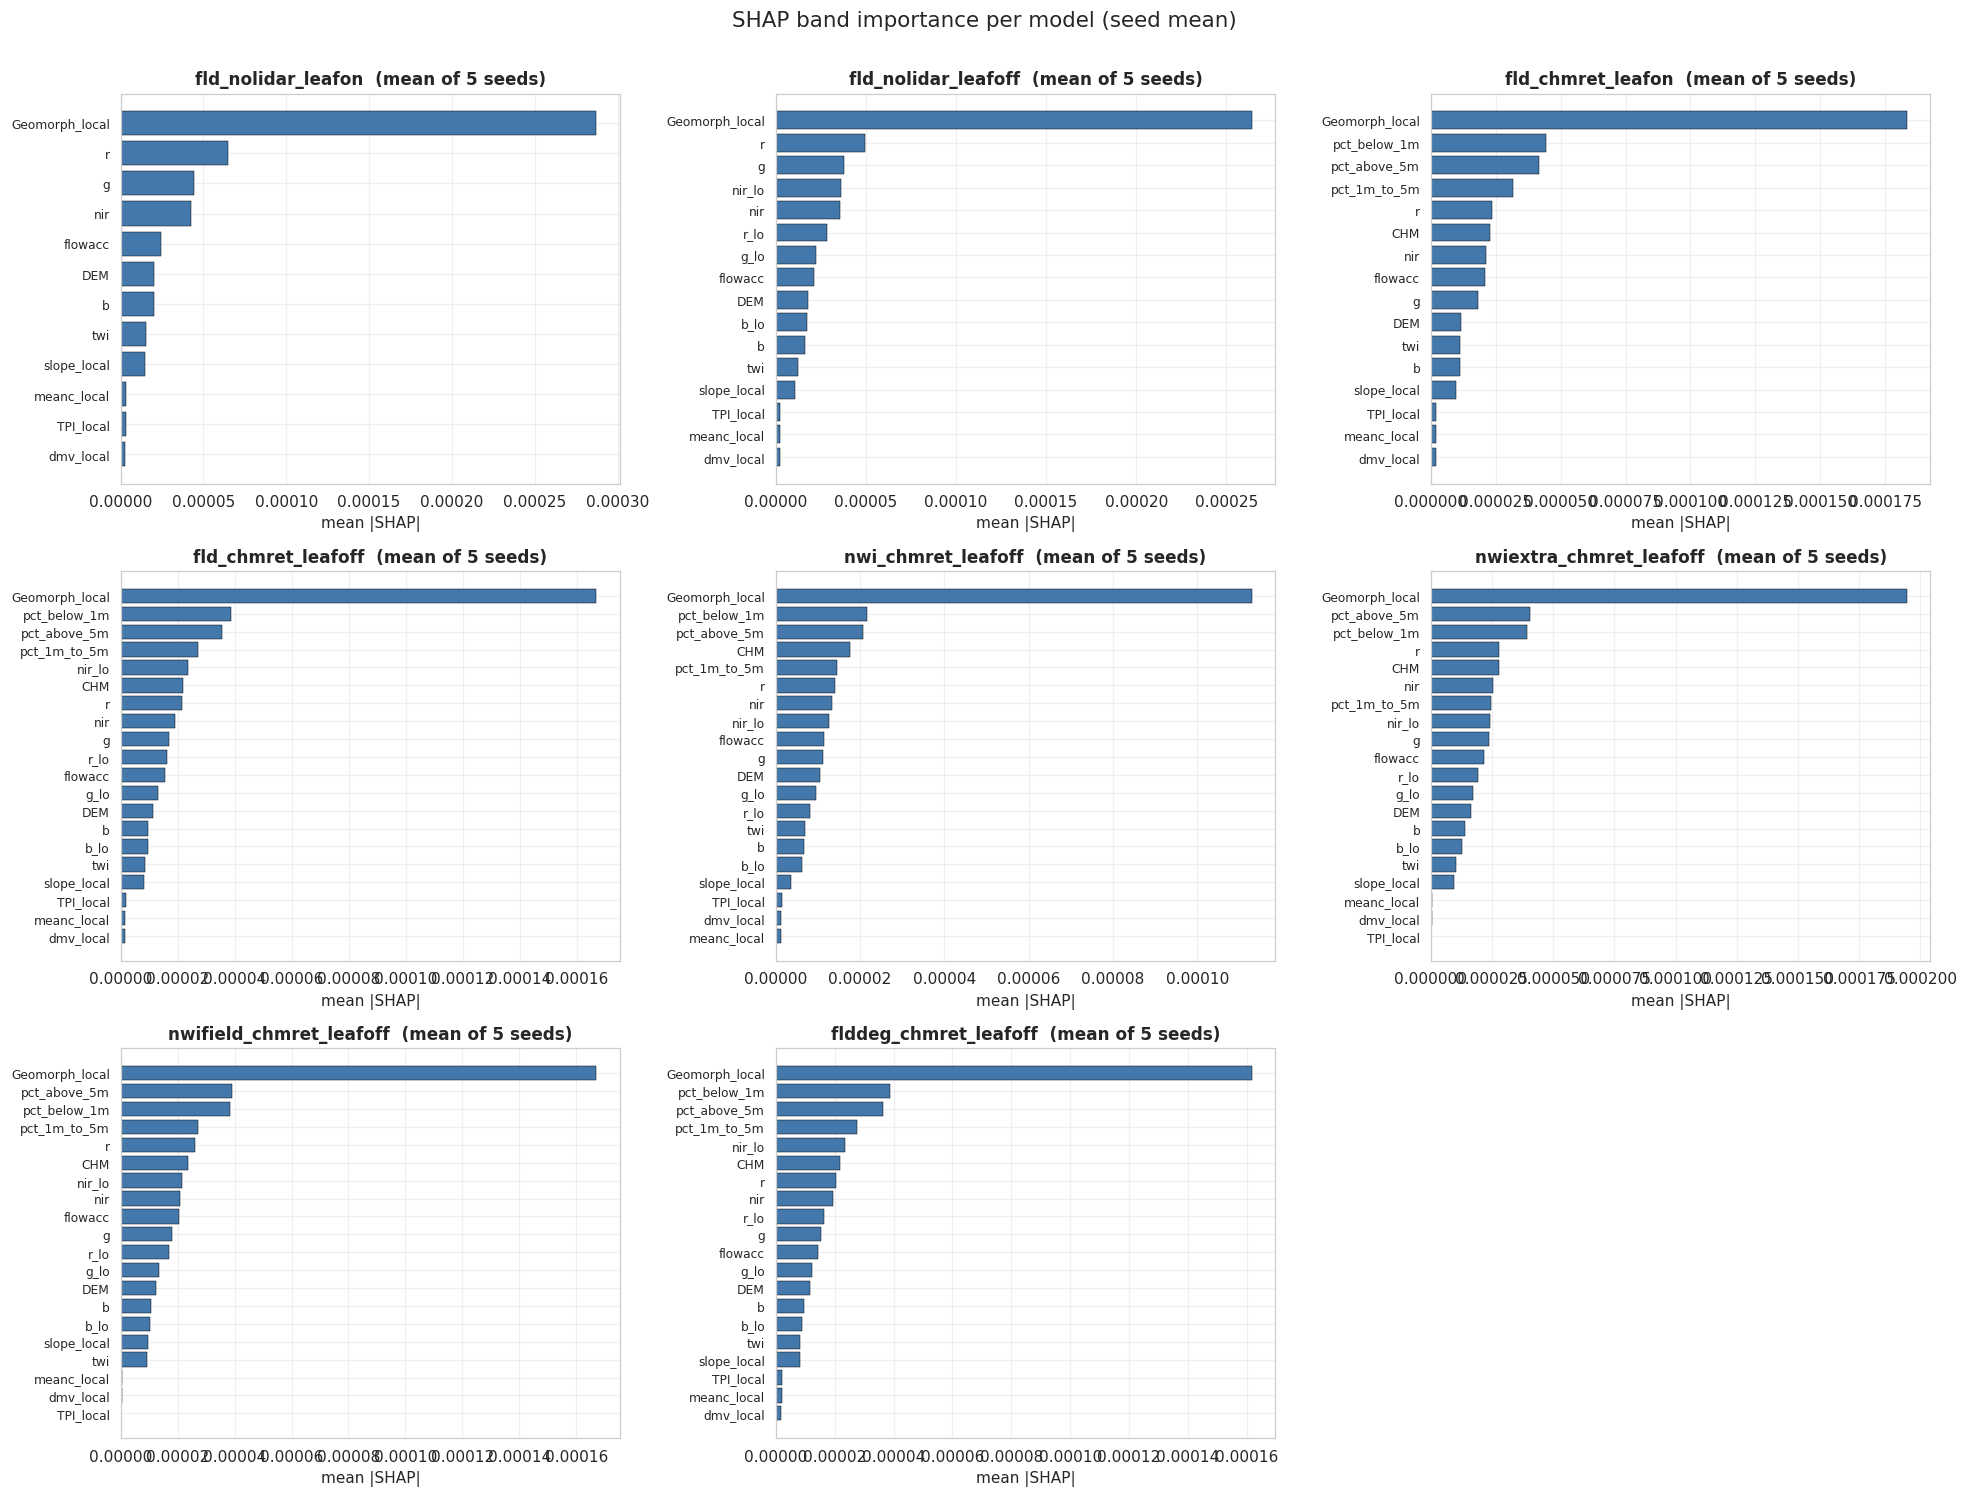

In [8]:
# Per-config SHAP bar charts (seed mean), sorted by importance.
n = len(shap_cfgs); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 4.5 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, cfg in zip(axes, shap_cfgs):
    s, k = shap_overall_mean(cfg)
    s = s.sort_values()
    ax.barh(range(len(s)), s.values, color="#4477aa", edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
    ax.set_title(f"{cfg}  (mean of {k} seeds)")
    ax.set_xlabel("mean |SHAP|")
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle("SHAP band importance per model (seed mean)", y=1.005, fontsize=14)
fig.tight_layout()
savefig(fig, "04_shap_per_model")
plt.show()


### 4a · One-hot aggregation check — sum vs per-channel mean

`run_shap` aggregates each band's channels by **summing** `|SHAP|`
(`dl_07_shap_analysis.py`). For the one-hot **`Geomorph_local`** band that is a sum
over **10** channels, while every continuous band is a single channel — so the sum
mechanically inflates Geomorphon's apparent importance relative to the
single-channel bands. The **per-channel mean** (`sum / n_channels`) is the
fair-per-channel view; a band's true standing sits **between** the two.

Because `n_channels` is exact and fixed (one-hot → `num_classes`, else 1), the mean
is recovered from the **already-saved JSONs without re-running SHAP**. Below: both
views side by side (one-hot bands flagged **red** are the only bars that move), plus
the per-config rank shift printed for each one-hot band. If Geomorphon stays near
the top under the mean, its importance is real; if it drops to mid-pack, the
headline rank was mostly the channel-count artifact.

Multi-channel (one-hot) bands: {'Geomorph_local': 10}
  fld_nolidar_leafon     Geomorph_local  rank  1/12 (sum)  ->   4/12 (per-channel mean)
  fld_nolidar_leafoff    Geomorph_local  rank  1/16 (sum)  ->   6/16 (per-channel mean)
  fld_chmret_leafon      Geomorph_local  rank  1/16 (sum)  ->   8/16 (per-channel mean)
  fld_chmret_leafoff     Geomorph_local  rank  1/20 (sum)  ->   9/20 (per-channel mean)
  nwi_chmret_leafoff     Geomorph_local  rank  1/20 (sum)  ->   9/20 (per-channel mean)
  nwiextra_chmret_leafoff Geomorph_local  rank  1/20 (sum)  ->  10/20 (per-channel mean)
  nwifield_chmret_leafoff Geomorph_local  rank  1/20 (sum)  ->  11/20 (per-channel mean)
  flddeg_chmret_leafoff  Geomorph_local  rank  1/20 (sum)  ->   9/20 (per-channel mean)


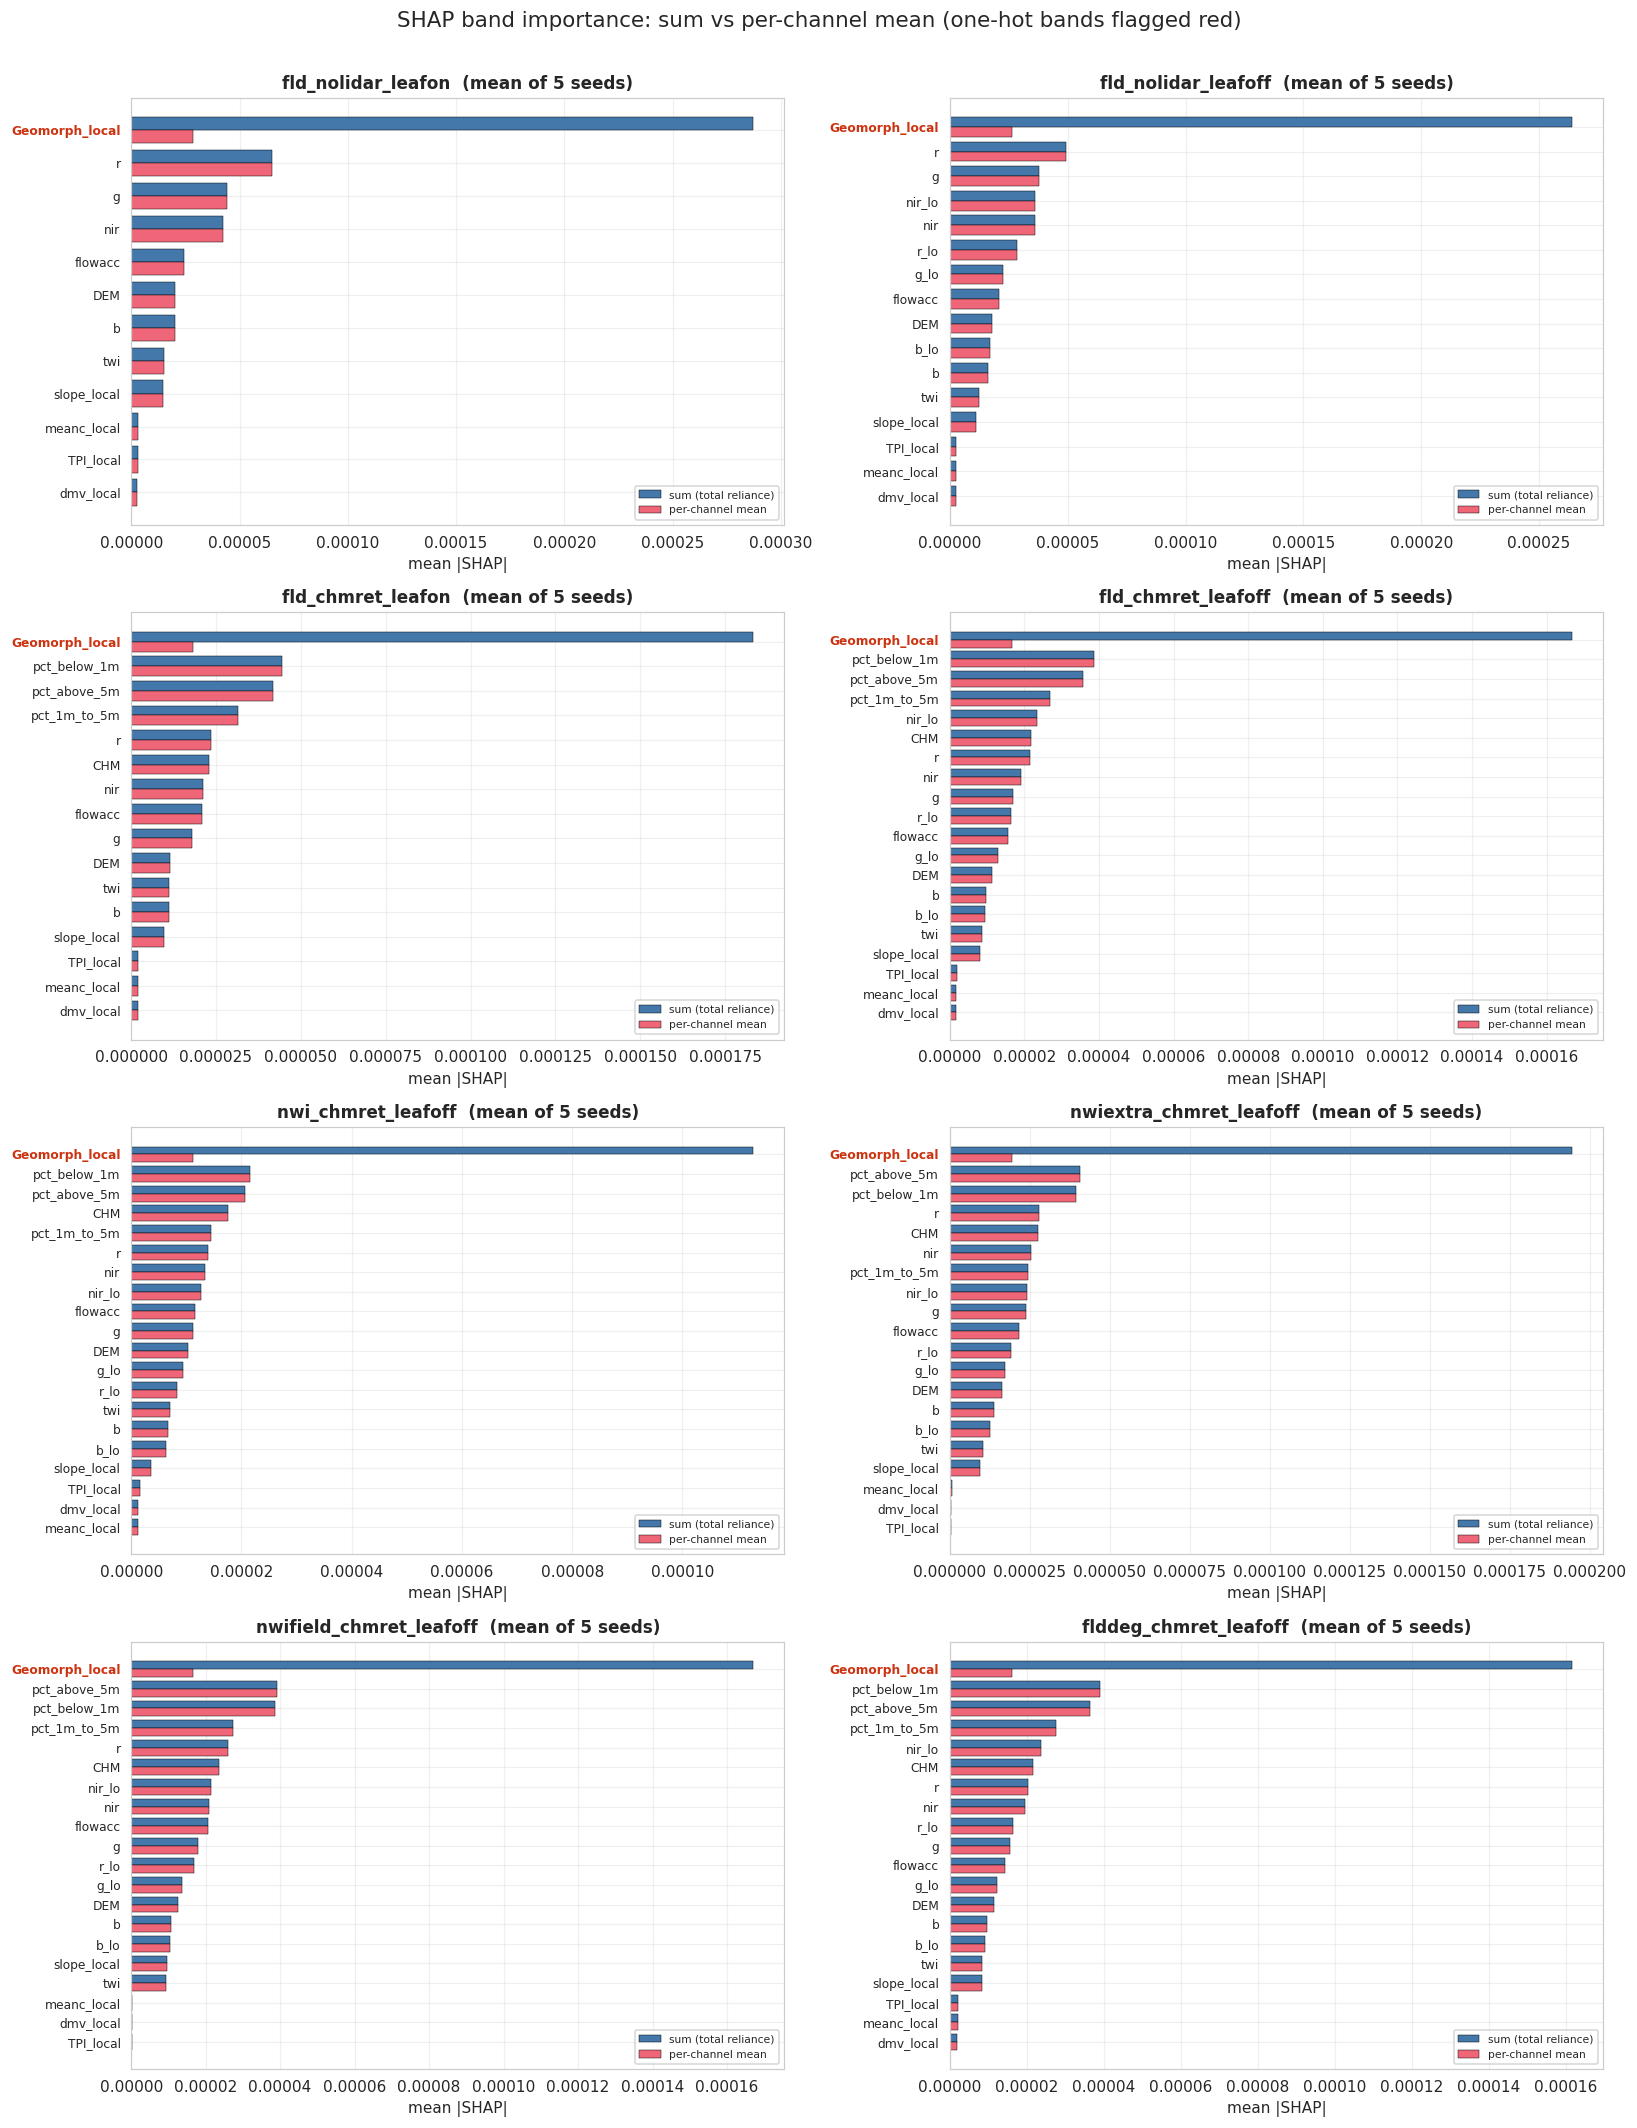

In [9]:
# --- Dual aggregation: SUM (total reliance) vs per-channel MEAN --------------
# run_shap aggregates each band's channels by SUMMING |SHAP| (dl_07_shap_analysis.py).
# For the one-hot Geomorph_local band that is a sum over 10 channels, while every
# continuous band is a single channel -- so the sum mechanically inflates the
# one-hot band vs the single-channel bands. The per-channel MEAN (= sum / n_channels)
# is the fair-per-channel view; the truth sits between the two. n_channels is exact
# and deterministic from the band-normalization config, so the mean is recovered
# from the already-saved JSONs WITHOUT re-running SHAP.

def _find_band_config():
    """Locate dl_band_config.json (the canonical normalization rules)."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in ("dl_band_config.json",
                    "Python_Code_Analysis/DL_Pipeline_v2/dl_band_config.json"):
            c = base / rel
            if c.is_file():
                return c
    c = Path("/ibstorage/anthony/NYS_Wetlands_DL/Python_Code_Analysis/"
             "DL_Pipeline_v2/dl_band_config.json")
    if c.is_file():
        return c
    raise FileNotFoundError("dl_band_config.json not found")

_BAND_NORM = json.loads(_find_band_config().read_text()).get("band_normalization", {})

def band_n_channels(band):
    """Expanded channel count for a band -- mirrors build_channel_mapping in
    dl_07_shap_analysis.py exactly (one_hot -> num_classes, everything else -> 1)."""
    cfg = _BAND_NORM.get(band, {})
    return int(cfg["num_classes"]) if cfg.get("method") == "one_hot" else 1

def shap_overall_dual(cfg):
    """(sum_series, mean_series, k_seeds): sum = saved per-band total |SHAP|;
    mean = per-channel (sum / n_channels). Identical except for one-hot bands."""
    s_sum, k = shap_overall_mean(cfg)
    nchan = pd.Series({b: band_n_channels(b) for b in s_sum.index})
    return s_sum, s_sum / nchan, k

# Report how far each multi-channel band's rank moves between the two views.
_multi = sorted({b for cfg in shap_cfgs for b in shap_overall_mean(cfg)[0].index
                 if band_n_channels(b) > 1})
print("Multi-channel (one-hot) bands:",
      {b: band_n_channels(b) for b in _multi} or "none -- all bands single-channel")
for cfg in shap_cfgs:
    s_sum, s_mean, _ = shap_overall_dual(cfg)
    r_sum = s_sum.rank(ascending=False).astype(int)
    r_mean = s_mean.rank(ascending=False).astype(int)
    for b in _multi:
        if b in s_sum.index:
            print(f"  {cfg:<22} {b:<15} rank {r_sum[b]:>2}/{len(s_sum)} (sum)"
                  f"  ->  {r_mean[b]:>2}/{len(s_mean)} (per-channel mean)")

# Dual horizontal bars per model: SUM vs per-channel MEAN, bands ordered by SUM.
# One-hot band labels are flagged red -- they are the only bars that move.
n = len(shap_cfgs); ncol = 2; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.5 * ncol, 4.8 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, cfg in zip(axes, shap_cfgs):
    s_sum, s_mean, k = shap_overall_dual(cfg)
    order = s_sum.sort_values().index
    y = np.arange(len(order)); h = 0.4
    ax.barh(y + h / 2, s_sum.reindex(order).values, height=h, color="#4477aa",
            edgecolor="black", linewidth=0.3, label="sum (total reliance)")
    ax.barh(y - h / 2, s_mean.reindex(order).values, height=h, color="#ee6677",
            edgecolor="black", linewidth=0.3, label="per-channel mean")
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
    for tick, b in zip(ax.get_yticklabels(), order):
        if band_n_channels(b) > 1:
            tick.set_color("#cc3311"); tick.set_fontweight("bold")
    ax.set_title(f"{cfg}  (mean of {k} seeds)")
    ax.set_xlabel("mean |SHAP|")
    ax.legend(fontsize=7, loc="lower right")
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle("SHAP band importance: sum vs per-channel mean (one-hot bands flagged red)",
             y=1.005, fontsize=14)
fig.tight_layout()
savefig(fig, "04_shap_dual_sum_mean")
plt.show()


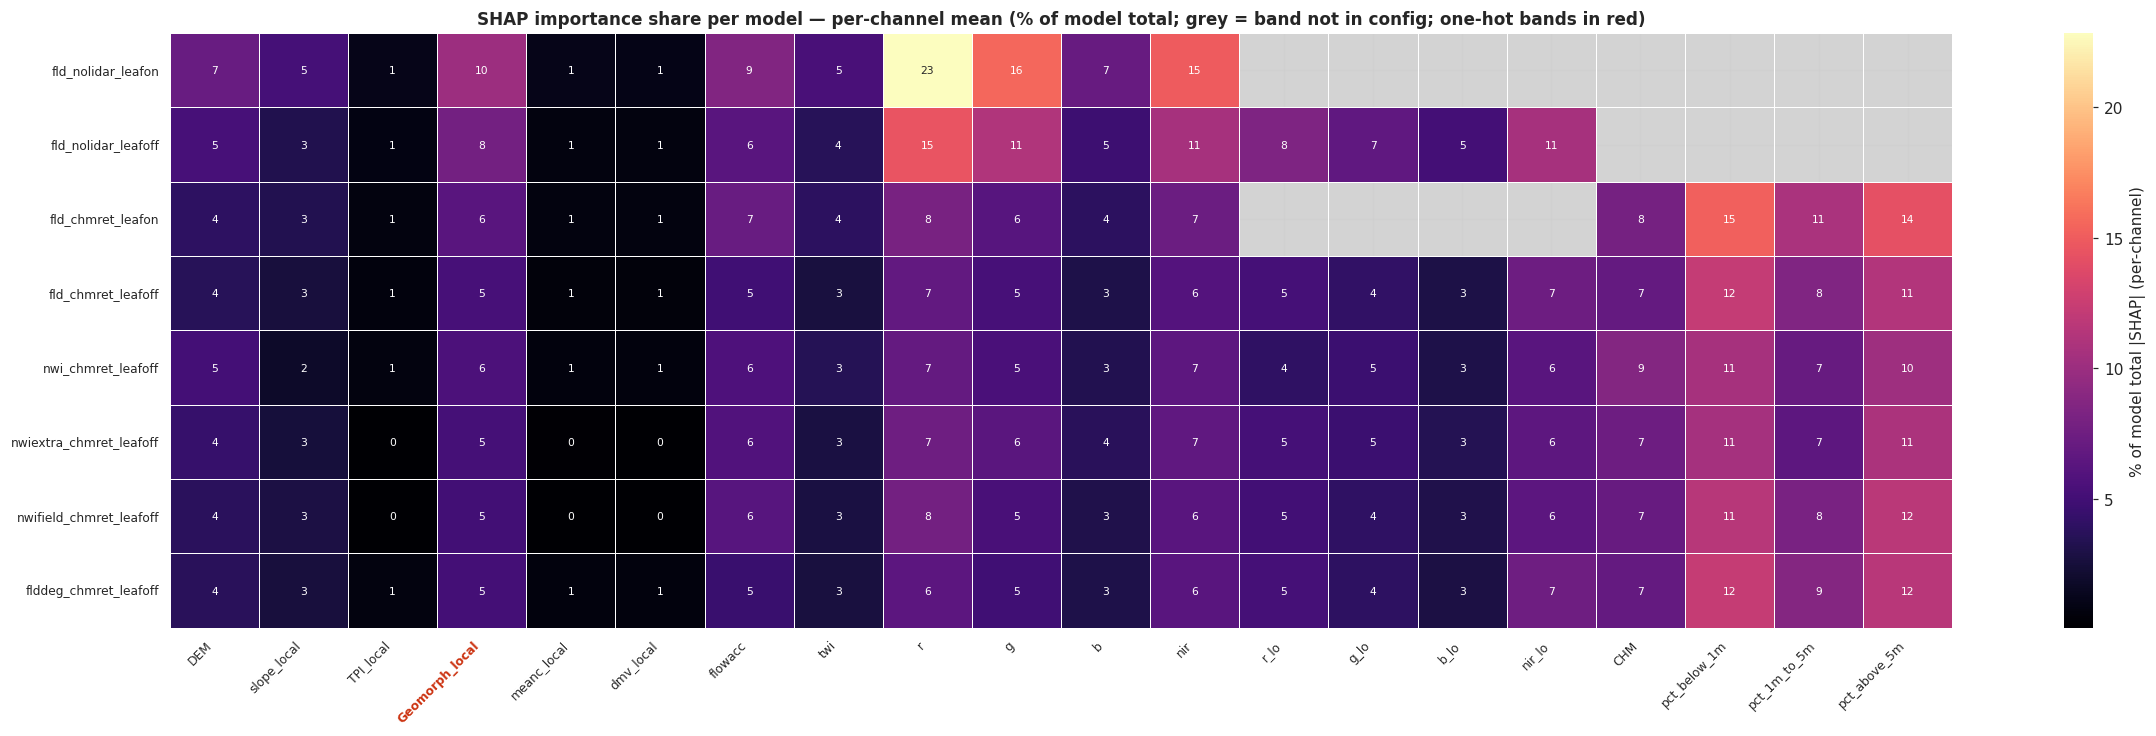

In [10]:
# Cross-model comparison: each model normalized to its own total importance,
# so bands are comparable across configs. Bands a config doesn't use are blank.
# Uses the PER-CHANNEL MEAN aggregation (not the raw sum) so the one-hot
# Geomorph_local band is not inflated 10x relative to single-channel bands.
all_bands = []
for cfg in shap_cfgs:
    for b in shap_overall_mean(cfg)[0].index:
        if b not in all_bands:
            all_bands.append(b)

norm = pd.DataFrame(index=shap_cfgs, columns=all_bands, dtype=float)
for cfg in shap_cfgs:
    _, s, _ = shap_overall_dual(cfg)          # per-channel mean
    norm.loc[cfg, s.index] = (s / s.sum()).values

fig, ax = plt.subplots(figsize=(1.0 * len(all_bands) + 2, 0.6 * len(shap_cfgs) + 2))
ax.set_facecolor("lightgray")        # shows through where a band is masked out
sns.heatmap(norm.astype(float) * 100, ax=ax, cmap="magma", mask=norm.isna(),
            annot=True, fmt=".0f", linewidths=0.5, linecolor="white",
            annot_kws={"fontsize": 7}, cbar_kws={"label": "% of model total |SHAP| (per-channel)"})
ax.set_yticklabels(shap_cfgs, rotation=0, fontsize=8)
# Flag one-hot bands on the x-axis (their share is per-channel, not summed).
ax.set_xticklabels(all_bands, rotation=45, ha="right", fontsize=8)
for tick, b in zip(ax.get_xticklabels(), all_bands):
    if band_n_channels(b) > 1:
        tick.set_color("#cc3311"); tick.set_fontweight("bold")
ax.set_title("SHAP importance share per model — per-channel mean "
             "(% of model total; grey = band not in config; one-hot bands in red)")
fig.tight_layout()
savefig(fig, "04_shap_share_heatmap")
plt.show()


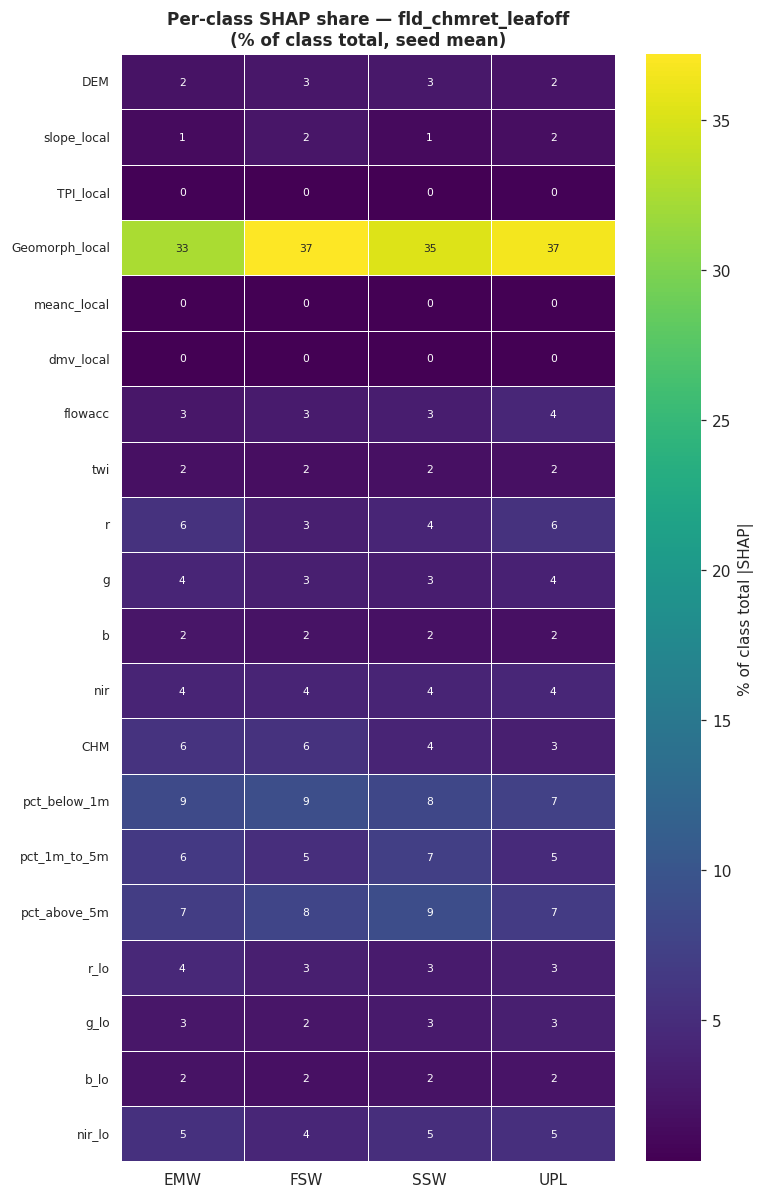

In [11]:
# Per-class SHAP for one config: band (rows) x class (cols), seed mean.
# Change FOCUS_CFG to inspect a different model.
FOCUS_CFG = "fld_chmret_leafoff" if "fld_chmret_leafoff" in shap_cfgs else shap_cfgs[0]

def shap_per_class_mean(cfg):
    seeds = shap_raw[cfg]
    bands = next(iter(seeds.values()))["bands"]
    classes = list(next(iter(seeds.values()))["per_class"].keys()) or CLASS_ORDER
    cube = np.array([[[s["per_class"][cls][b] for cls in classes] for b in bands]
                     for s in seeds.values()])          # (seed, band, class)
    return pd.DataFrame(cube.mean(axis=0), index=bands, columns=classes)

pc = shap_per_class_mean(FOCUS_CFG)
pc_norm = pc / pc.sum(axis=0)        # share within each class

fig, ax = plt.subplots(figsize=(7, 0.45 * len(pc) + 2))
sns.heatmap(pc_norm * 100, ax=ax, cmap="viridis", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", annot_kws={"fontsize": 7},
            cbar_kws={"label": "% of class total |SHAP|"})
ax.set_yticklabels(pc.index, rotation=0, fontsize=8)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title(f"Per-class SHAP share — {FOCUS_CFG}\n(% of class total, seed mean)")
fig.tight_layout()
savefig(fig, "04_shap_per_class")
plt.show()


### 4b · Within-Geomorphon breakdown — *which* form drives the band

§4a tells us *how much* of Geomorphon's rank is channel-count inflation; this tells
us *whether the remaining signal is real*. Using the per-channel array
(`{stem}_shap_per_channel.npz`, written by the updated `run_shap`), we split the
one-hot `Geomorph_local` band back into its 10 geomorphon forms and rank them.

- **Concentrated** in a few forms (e.g. `valley` / `depression` / `footslope` — the
  wet landform positions) → the band carries genuine landform signal the model
  exploits.
- **Smeared** evenly across all 10 forms (top-3 share ≈ 30%) → the high *summed*
  rank was mostly the 10-channel artifact, not real reliance on landform.

Each form is a one-hot channel, so GradientSHAP attributes to both its *presence*
and *absence* — a high value means the model keys on that form being on **or** off.
**Requires a post-update `dl_09 --force` re-run** to produce the `.npz` files; the
cell prints a hint and no-ops until they exist.

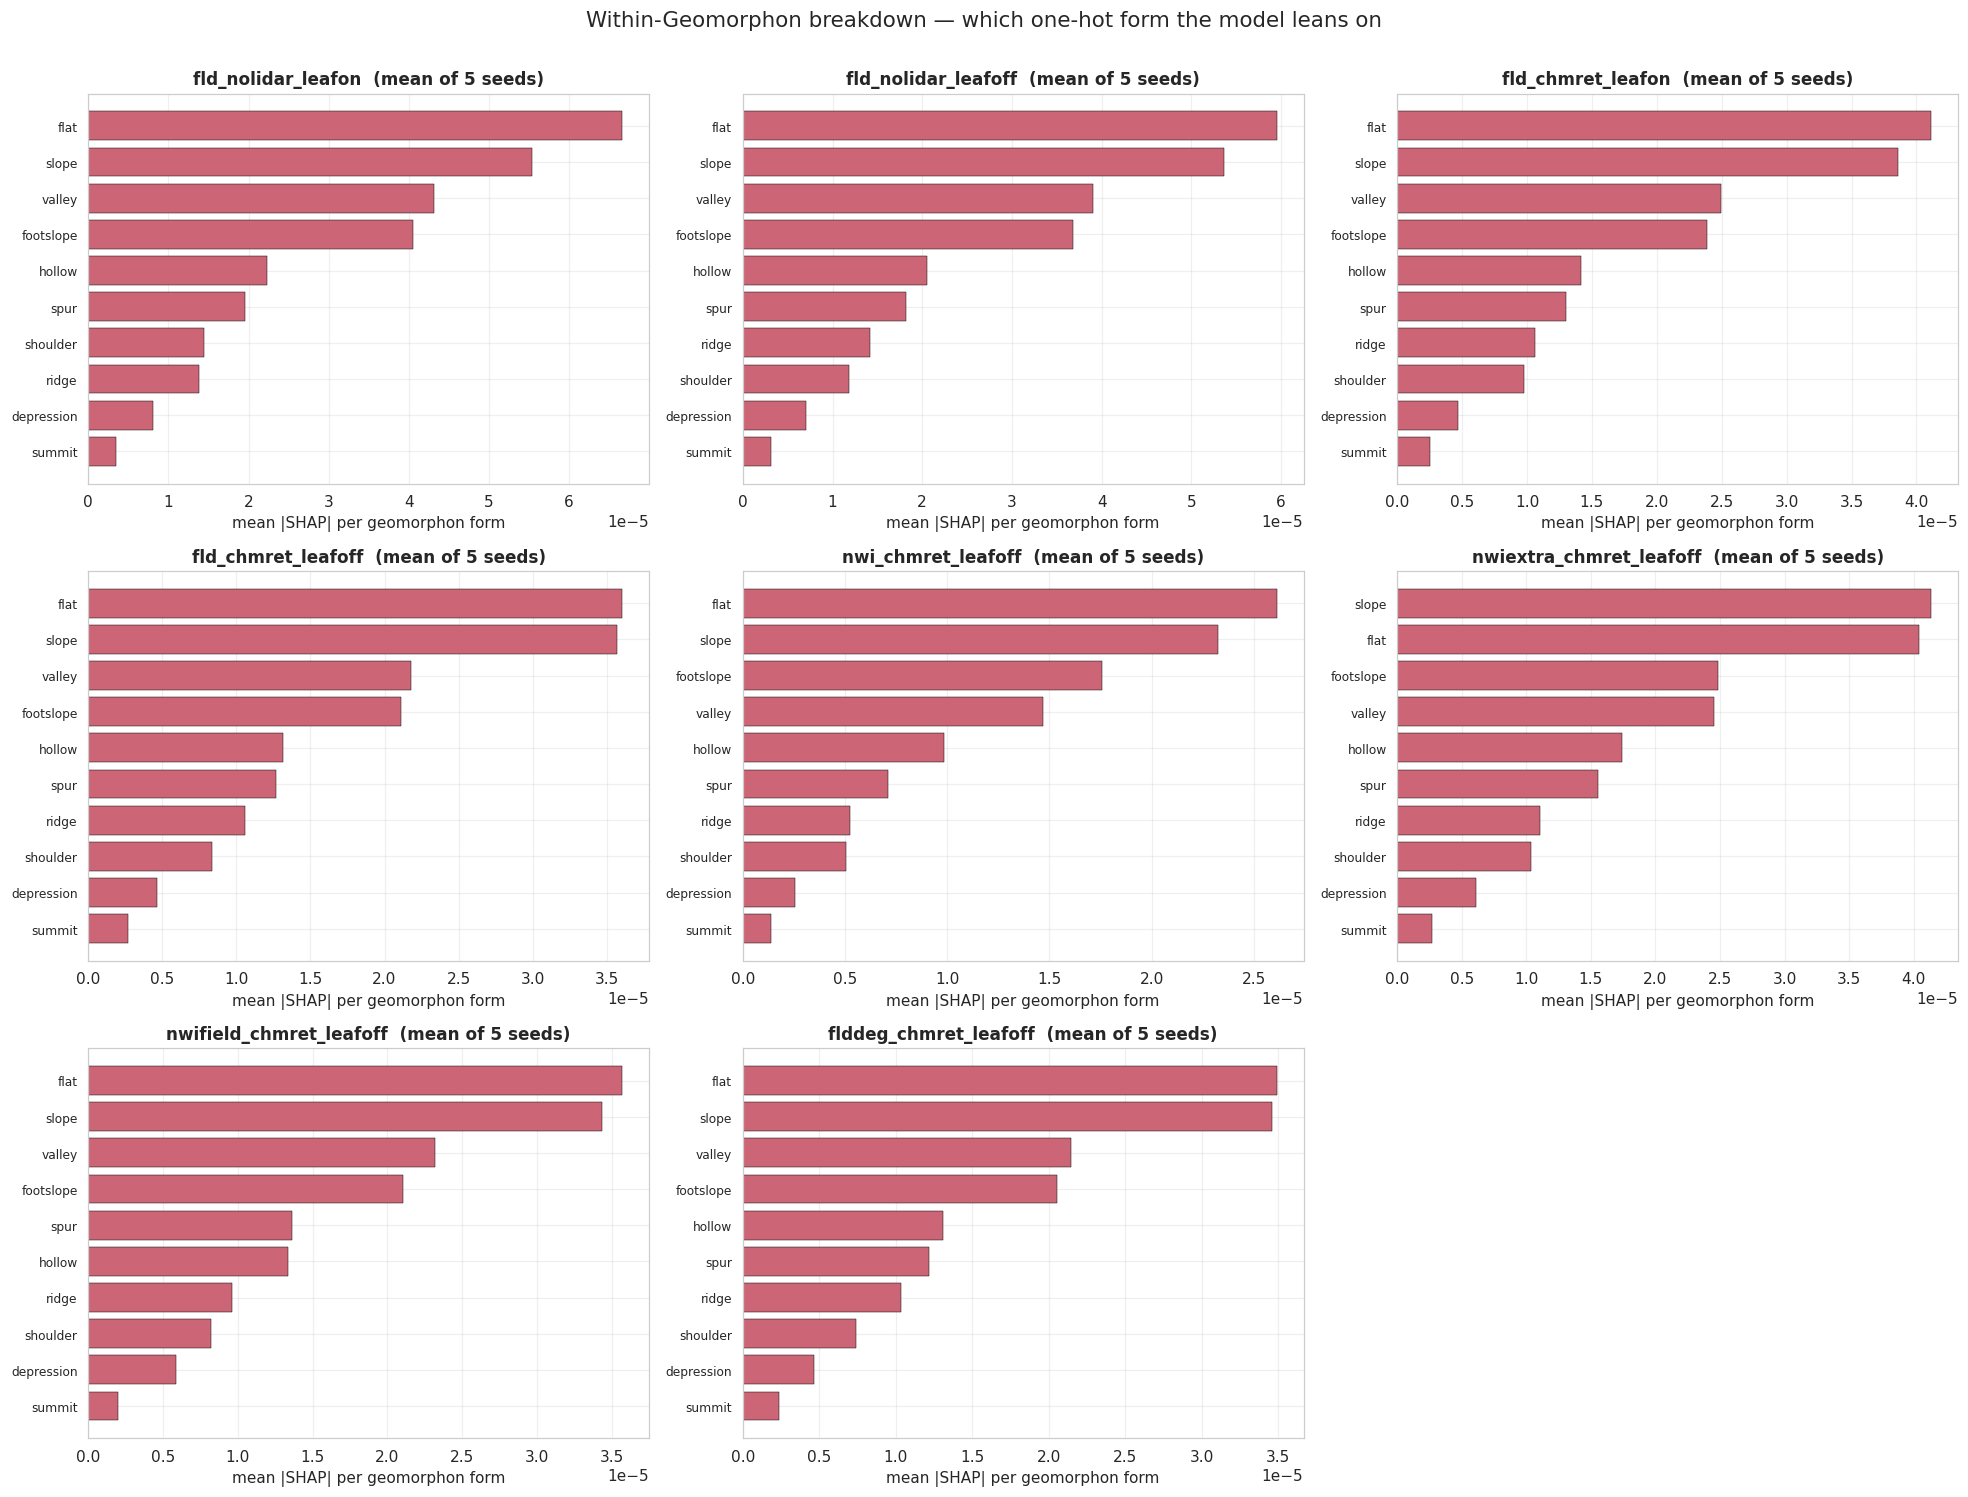

Geomorphon concentration (share of the band's |SHAP|):
  fld_nolidar_leafon     lead = flat        top1=23.2%  top3=57.5%
  fld_nolidar_leafoff    lead = flat        top1=22.6%  top3=57.7%
  fld_chmret_leafon      lead = flat        top1=22.4%  top3=57.1%
  fld_chmret_leafoff     lead = flat        top1=21.6%  top3=56.1%
  nwi_chmret_leafoff     lead = flat        top1=23.2%  top3=59.3%
  nwiextra_chmret_leafoff lead = slope       top1=21.3%  top3=54.9%
  nwifield_chmret_leafoff lead = flat        top1=21.4%  top3=55.9%
  flddeg_chmret_leafoff  lead = flat        top1=21.6%  top3=56.3%


In [12]:
# --- Within-Geomorphon breakdown (needs the per-channel .npz) ----------------
# run_shap (post-update) writes {stem}_shap_per_channel.npz next to the JSON:
#   shap_abs (n_classes, n_test, C_input), channel_band (parent band per channel).
# Splitting the one-hot Geomorph_local band back into its 10 geomorphon forms
# shows WHICH form the model leans on -- the diagnostic that tells "real signal
# concentrated in a few forms" apart from "smeared across all 10" (the summation
# artifact). Only present after a `dl_09 ... --force` re-run; no-ops gracefully
# (prints a hint) until the .npz files exist.

GEOMORPH_FORMS = {            # r.geomorphon class_range [1,10] -> standard form name
    1: "flat", 2: "summit", 3: "ridge", 4: "shoulder", 5: "spur",
    6: "slope", 7: "hollow", 8: "footslope", 9: "valley", 10: "depression",
}
ONEHOT_BAND = "Geomorph_local"

def load_geomorph_breakdown(cfg):
    """Seed-mean per-form mean|SHAP| for the one-hot band, or None if no .npz."""
    per_seed = []
    for seed_dir in sorted((RESULTS_DIR / cfg).glob("seed*")):
        npzs = list(seed_dir.glob("shap/*_shap_per_channel.npz"))
        if not npzs:
            continue
        z = np.load(npzs[0])
        idx = np.where(z["channel_band"].astype(str) == ONEHOT_BAND)[0]
        if idx.size == 0:
            continue
        # shap_abs: (n_classes, n_test, C) -> mean over classes & test -> (n_forms,)
        per_seed.append(z["shap_abs"][:, :, idx].mean(axis=(0, 1)))
    if not per_seed:
        return None
    m = np.mean(per_seed, axis=0)
    forms = [GEOMORPH_FORMS.get(i + 1, f"form{i + 1}") for i in range(len(m))]
    return pd.Series(m, index=forms), len(per_seed)

_geo = {cfg: load_geomorph_breakdown(cfg) for cfg in shap_cfgs}
_geo = {c: v for c, v in _geo.items() if v is not None}

if not _geo:
    print("No *_shap_per_channel.npz found yet. Re-run dl_09_shap_factorial.py with "
          "--force (post-update run_shap) to generate them, then re-run this cell.")
else:
    n = len(_geo); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 4.5 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, (cfg, (s, k)) in zip(axes, _geo.items()):
        s = s.sort_values()
        ax.barh(range(len(s)), s.values, color="#cc6677", edgecolor="black", linewidth=0.3)
        ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
        ax.set_title(f"{cfg}  (mean of {k} seeds)")
        ax.set_xlabel("mean |SHAP| per geomorphon form")
    for ax in axes[len(_geo):]:
        ax.axis("off")
    fig.suptitle("Within-Geomorphon breakdown — which one-hot form the model leans on",
                 y=1.005, fontsize=14)
    fig.tight_layout()
    savefig(fig, "04b_geomorph_form_breakdown")
    plt.show()

    # Concentration check: is the band's signal in a few forms (real) or smeared
    # across all 10 (the artifact)? An even smear over 10 forms => top3 ~30%.
    print("Geomorphon concentration (share of the band's |SHAP|):")
    for cfg, (s, k) in _geo.items():
        tot = s.sum()
        top1 = s.max() / tot * 100
        top3 = s.sort_values(ascending=False).head(3).sum() / tot * 100
        print(f"  {cfg:<22} lead = {s.idxmax():<11} top1={top1:4.1f}%  top3={top3:4.1f}%")


## 5 · Extra views worth having

### 5a · Contrasts forest plot — *the actual experiment result*

`contrasts.csv` holds the paired-by-seed effects the factorial was designed to
estimate: each LiDAR tier's gain, the leaf-off main effect, the LiDAR×leaf-off
interaction, and the label gradient (NWI vs field vs degraded). A forest plot
(Δ ± sd, paired over seeds) reads these directly — points right of the dashed
zero line are improvements. This is more informative than the absolute bars
because it nets out per-seed split luck.

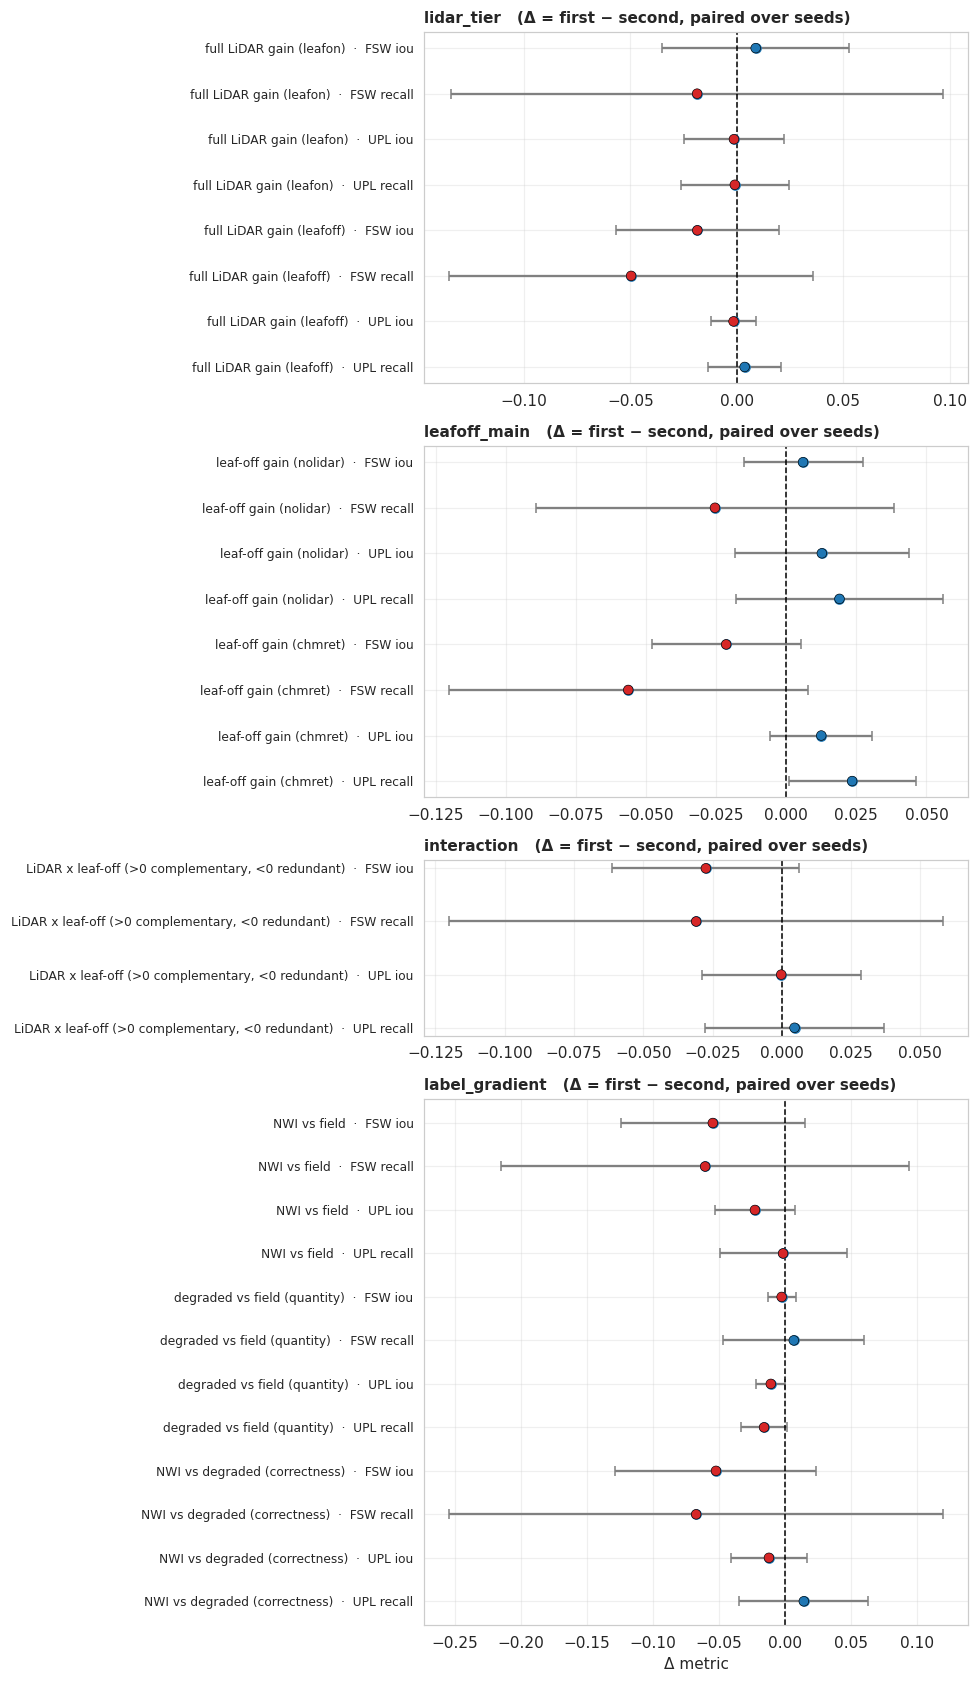

In [13]:
cdf = contrasts.copy()
# One readable row label per contrast x class x metric.
cdf["row"] = cdf["note"].fillna(cdf["contrast"]) + "  ·  " + cdf["class"] + " " + cdf["metric"]

groups = ["lidar_tier", "leafoff_main", "interaction", "label_gradient"]
present_groups = [g for g in groups if g in set(cdf["group"])]
fig, axes = plt.subplots(len(present_groups), 1,
                         figsize=(9, 1 + 0.45 * len(cdf)),
                         gridspec_kw={"height_ratios":
                             [max((cdf["group"] == g).sum(), 1) for g in present_groups]})
axes = np.atleast_1d(axes)
for ax, g in zip(axes, present_groups):
    sub = cdf[cdf["group"] == g].reset_index(drop=True)
    y = np.arange(len(sub))
    colors = ["#1f77b4" if m >= 0 else "#d62728" for m in sub["delta_mean"]]
    ax.errorbar(sub["delta_mean"], y, xerr=sub["delta_sd"].fillna(0),
                fmt="o", capsize=3, ecolor="gray", linestyle="none")
    ax.scatter(sub["delta_mean"], y, c=colors, zorder=3, s=40, edgecolor="black", linewidth=0.4)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(sub["row"], fontsize=8)
    ax.set_title(f"{g}   (Δ = first − second, paired over seeds)", fontsize=10, loc="left")
    ax.invert_yaxis()
axes[-1].set_xlabel("Δ metric")
fig.tight_layout()
savefig(fig, "05a_contrasts_forest")
plt.show()


### 5b · Seed variability

How much does the seed (the train/val/test split + init) move each headline
number? Tight clusters mean the contrasts above are trustworthy; wide spreads
mean a difference may be split luck.

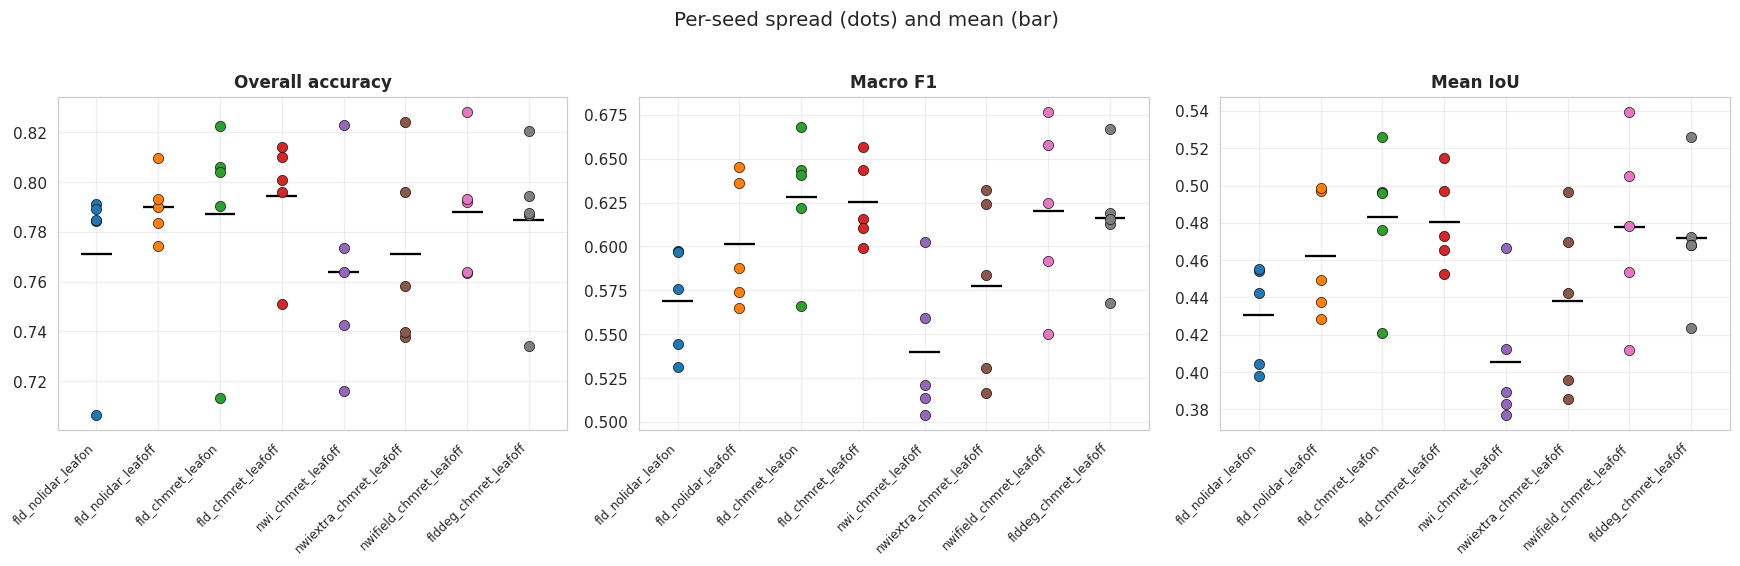

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, title) in zip(axes, OVERALL_METRICS):
    for i, cfg in enumerate(present_cfgs):
        vals = cell.loc[cell["config"] == cfg, col].values
        ax.scatter(np.full_like(vals, i, dtype=float), vals,
                   color=CONFIG_COLORS[cfg], s=45, edgecolor="black", linewidth=0.4, zorder=3)
        ax.hlines(vals.mean(), i - 0.25, i + 0.25, color="black", linewidth=1.5)
    ax.set_xticks(range(len(present_cfgs)))
    ax.set_xticklabels(present_cfgs, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
fig.suptitle("Per-seed spread (dots) and mean (bar)", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, "05b_seed_variability")
plt.show()


### 5c · Reliance vs ablation — does SHAP agree with the experiment?

The factorial's design intent (plan §8.5) is to pair feature **reliance** (SHAP
importance — how much the model *leans* on a band) against feature **ablation**
(the contrast Δ — how much *adding* that feature actually *moved* the metric). A
band can be heavily relied on yet add little when removed (redundant), or be a
modest reliance yet a real marginal gain (complementary). Here we line up the
LiDAR/leaf-off bands' SHAP share in the full model against their ablation gains
from `contrasts.csv`.

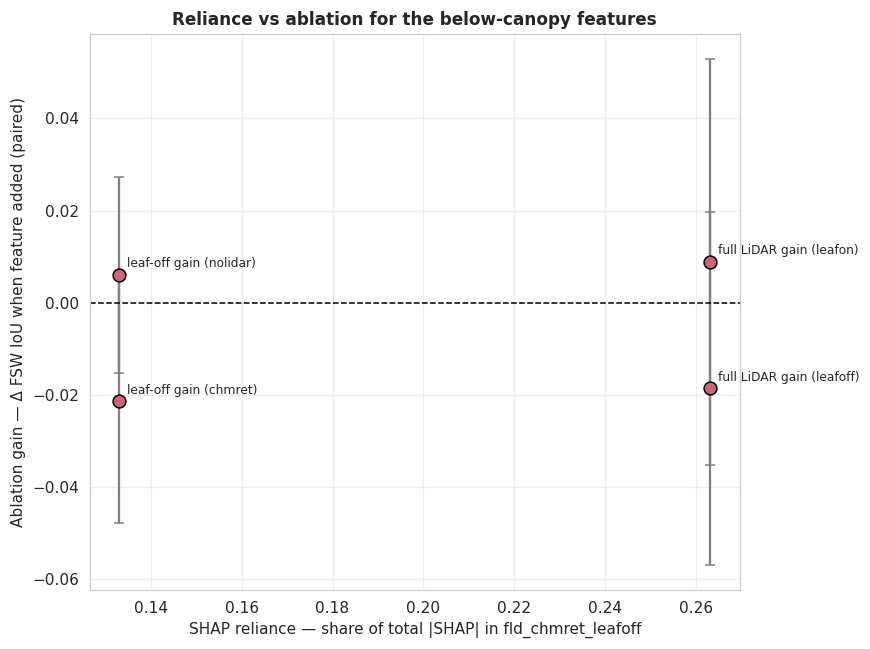

In [15]:
# Marginal gains (from contrasts) for the feature additions, FSW IoU as the lead metric.
abl = contrasts[(contrasts["group"].isin(["lidar_tier", "leafoff_main"])) &
                (contrasts["class"] == "FSW") & (contrasts["metric"] == "iou")].copy()

if not abl.empty and shap_cfgs:
    # SHAP reliance: share of the bands that each addition introduces, in the
    # full field model (chmret_leafoff) — the most-loaded reference cell.
    ref = "fld_chmret_leafoff"
    if ref in shap_cfgs:
        share, _ = shap_overall_mean(ref)
        share = share / share.sum()
        ADD_BANDS = {
            "chm gain": ["CHM"],
            "returns gain": ["pct_below_1m", "pct_1m_to_5m", "pct_above_5m"],
            "full LiDAR gain": ["CHM", "pct_below_1m", "pct_1m_to_5m", "pct_above_5m"],
            "leaf-off gain": ["r_lo", "g_lo", "b_lo", "nir_lo"],
        }
        rows = []
        for _, r in abl.iterrows():
            for key, bands in ADD_BANDS.items():
                if key in str(r["note"]):
                    rel = share.reindex(bands).dropna().sum()
                    rows.append({"note": r["note"], "ablation_gain": r["delta_mean"],
                                 "ablation_sd": r["delta_sd"], "shap_share": rel})
                    break
        rel_df = pd.DataFrame(rows).drop_duplicates("note")

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.errorbar(rel_df["shap_share"], rel_df["ablation_gain"],
                    yerr=rel_df["ablation_sd"].fillna(0), fmt="o", capsize=3,
                    ecolor="gray", linestyle="none", zorder=2)
        ax.scatter(rel_df["shap_share"], rel_df["ablation_gain"], s=70,
                   c="#cc6677", edgecolor="black", zorder=3)
        for _, r in rel_df.iterrows():
            ax.annotate(r["note"], (r["shap_share"], r["ablation_gain"]),
                        fontsize=8, xytext=(5, 5), textcoords="offset points")
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("SHAP reliance — share of total |SHAP| in fld_chmret_leafoff")
        ax.set_ylabel("Ablation gain — Δ FSW IoU when feature added (paired)")
        ax.set_title("Reliance vs ablation for the below-canopy features")
        fig.tight_layout()
        savefig(fig, "05c_reliance_vs_ablation")
        plt.show()
    else:
        print("Reference config fld_chmret_leafoff has no SHAP yet — skipping 5c.")
else:
    print("Not enough SHAP/contrast data for the reliance-vs-ablation plot yet.")


---
All figures are also written to `Models/factorial_results/analysis/figures/` for
dropping into the write-up. Re-run top-to-bottom after each `run_aggregate.sh` /
`dl_09_shap_factorial.py` pass — it picks up new cells automatically.

## 6 · Patch-count learning curve

How much does accuracy improve as the labeled training pool grows? Each level
(`n100 … n500`, then `full`) trains the best field config at a capped #patches,
3 seeds per level. The x-axis is the **realized** #train patches
(`training_log.json → data_split.train`), not the requested cap, so the curve
stays honest as the dataset grows (plan §9, `run_patchcurve.sh`).

In [16]:
# --- Follow-on study locations (siblings of factorial_results under Models/) ---
# MODELS_DIR + with_mode() come from the Setup cell; with_mode() appends the
# resolved <mode> level so v2's results_patchcurve_v2/<mode>/... resolves while
# v1 (no mode level) is untouched.
PATCHCURVE_DIR = with_mode(MODELS_DIR / f"results_patchcurve{_SUFFIX}")
ARCH_DIR       = with_mode(MODELS_DIR / f"results_arch{_SUFFIX}")
PRED_DIR       = MODELS_DIR.parent / "Data" / f"HUC_DL_Predictions{_SUFFIX}"
for p in (PATCHCURVE_DIR, ARCH_DIR, PRED_DIR):
    print(("ok      " if p.exists() else "MISSING "), p)

# Walk the patch-curve tree directly (same parse as dl_08b_aggregate_patchcurve)
# so every per-class metric is available, not just the IoU in the summary CSV.
import re
_LEVEL_RE = re.compile(r"_n(?P<level>\d+|full)$")

def load_patchcurve(results_dir):
    """Long frame: one row per (level, seed, class) with overall + per-class metrics.
    x-axis truth = realized #train patches from training_log.json (data_split.train)."""
    rows = []
    dirs = sorted(p for p in results_dir.iterdir() if p.is_dir()) if results_dir.is_dir() else []
    for cfg_dir in dirs:
        mlev = _LEVEL_RE.search(cfg_dir.name)
        if not mlev:
            continue
        level = mlev.group("level")
        config = cfg_dir.name[: mlev.start()]
        level_sort = np.inf if level == "full" else int(level)
        for seed_dir in sorted(cfg_dir.glob("seed*")):
            if not seed_dir.name[4:].isdigit():
                continue
            mfile = seed_dir / "metrics.json"
            if not mfile.exists():
                continue
            sc = _scores(json.loads(mfile.read_text()))   # unwrap v2 test_metrics
            train = None
            log = seed_dir / "training_log.json"
            if log.exists():
                entries = json.loads(log.read_text())
                if entries:
                    train = entries[-1].get("data_split", {}).get("train")
            base = dict(config=config, level=level, level_sort=level_sort,
                        seed=int(seed_dir.name[4:]), train_patches=train,
                        overall_accuracy=sc.get("overall_accuracy"),
                        macro_f1=sc.get("macro_f1"),
                        mean_iou=sc.get("mean_iou"))
            for cls, cm in sc.get("per_class", {}).items():
                rows.append({**base, "class": cls,
                             "recall": cm.get("recall"), "precision": cm.get("precision"),
                             "f1": cm.get("f1"), "iou": cm.get("iou")})
    return pd.DataFrame(rows)

pcurve = load_patchcurve(PATCHCURVE_DIR)
PC_CFG = pcurve["config"].iloc[0] if not pcurve.empty else "fld_chmret_leafoff"
levels = sorted(pcurve["level"].unique(), key=lambda l: (l == "full", l)) if not pcurve.empty else []
print(f"\npatch-curve: {len(pcurve)} rows · config {PC_CFG} · levels {levels} · "
      f"seeds {sorted(pcurve['seed'].unique()) if not pcurve.empty else []}")
pcurve.head()

MISSING  /local/workdir/ajs544/nys_wetlands/Models/results_patchcurve_v3/multiclass
ok       /local/workdir/ajs544/nys_wetlands/Models/results_arch_v3/multiclass
ok       /local/workdir/ajs544/nys_wetlands/Data/HUC_DL_Predictions_v3

patch-curve: 0 rows · config fld_chmret_leafoff · levels [] · seeds []


""


In [17]:
# Learning curve, mean ± sd over seeds, x = realized #train patches.
if pcurve.empty:
    print("No patch-curve cells under", PATCHCURVE_DIR, "- skipping section 6.")
else:
    ov = (pcurve.drop_duplicates(["level_sort", "seed"])
                .groupby("level_sort", as_index=False)
                .agg(train=("train_patches", "mean"),
                     mf1_m=("macro_f1", "mean"), mf1_s=("macro_f1", "std"),
                     miou_m=("mean_iou", "mean"), miou_s=("mean_iou", "std"))
                .sort_values("train"))
    pc = (pcurve.groupby(["level_sort", "class"], as_index=False)
                .agg(train=("train_patches", "mean"),
                     iou_m=("iou", "mean"), iou_s=("iou", "std")))

    # 6a · overall accuracy vs training-set size
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(ov["train"], ov["mf1_m"], yerr=ov["mf1_s"].fillna(0),
                marker="o", capsize=3, color="#1f77b4", label="macro F1")
    ax.errorbar(ov["train"], ov["miou_m"], yerr=ov["miou_s"].fillna(0),
                marker="s", linestyle="--", capsize=3, color="#d62728", label="mean IoU")
    ax.set_xlabel("realized #train patches"); ax.set_ylabel("score")
    ax.set_title(f"Accuracy vs training-set size  ({PC_CFG}, mean ± sd over seeds)")
    ax.legend()
    fig.tight_layout(); savefig(fig, "06_patchcurve_overall"); plt.show()

    # 6b · per-class IoU vs training-set size
    fig, ax = plt.subplots(figsize=(8, 5))
    for cls in CLASS_ORDER:
        s = pc[pc["class"] == cls].sort_values("train")
        if s.empty:
            continue
        ax.errorbar(s["train"], s["iou_m"], yerr=s["iou_s"].fillna(0),
                    marker="o", capsize=3, color=CLASS_COLORS.get(cls), label=cls)
    ax.set_xlabel("realized #train patches"); ax.set_ylabel("per-class IoU")
    ax.set_title("Per-class IoU vs training-set size"); ax.legend()
    fig.tight_layout(); savefig(fig, "06_patchcurve_per_class"); plt.show()

No patch-curve cells under /local/workdir/ajs544/nys_wetlands/Models/results_patchcurve_v3/multiclass - skipping section 6.


## 7 · Architecture comparison — U-Net vs UNet3+ vs mbfusion

Three network arms on **one** config (`fld_chmret_leafoff`, the full 29-channel
feature set), **both modes**, **the same 5 seeds**, with bf64 / d5 / 50 epochs
held fixed — so the only thing that varies is the network:

| Arm | Cell root |
|---|---|
| **U-Net** (residual + SE) — the baseline | `Models/factorial_results_v3/<mode>/fld_chmret_leafoff/` |
| **UNet3+** (full-scale skips + deep supervision) | `Models/results_arch_v3/<mode>/…_unet3plus/` |
| **mbfusion** (per-modality encoders + per-pixel gated fusion) | `Models/results_arch_fusion_v3/<mode>/…_mbfusion/` |

The arm list is data, not hardcoded plotting: every figure below loops over
whatever arms are present, so adding a fourth arm is one line in the next cell.

Loading and the paired contrast are **imported from `dl_08b_aggregate_patchcurve`**
rather than re-implemented, so this notebook and `arch_compare_long.csv` /
`arch_contrasts.csv` agree by construction — including the cost columns and the
row-normalized confusion rates. It reads the per-cell `metrics.json` /
`confusion_matrix.csv` / `training_log.json` / `train.log` directly, so it works
before `dl_08b` has been run and stays honest on a partial tree.

**At n=5 the credible summary is sign consistency** (`n_better`/`n_seeds`), not a
p-value — same seed ⇒ same test patches, so every delta is paired. Deliberately
no significance tests (`PLAN.md` §9).

In [18]:
# --- Section 7 setup: declare the arms and load every cell -------------------
# Roots are declared HERE rather than inherited from §6 so this section stands
# alone -- the patch-count curve is dropped from v3 and §6 may be skipped.
ARCH_CFG      = "fld_chmret_leafoff"   # the one config run in all three arms
ARCH_BASELINE = "unet"                 # deltas are measured against this arm

# (name, root). `name` must match the arch driver's CELL_NAME suffix; the base
# grid's cells are NOT suffixed, which _cell_dir() handles. Order = plot order.
ARCH_ARMS = [
    ("unet",      MODELS_DIR / f"factorial_results{_SUFFIX}"),
    ("unet3plus", MODELS_DIR / f"results_arch{_SUFFIX}"),
    ("mbfusion",  MODELS_DIR / f"results_arch_fusion{_SUFFIX}"),
]
ARCH_LABEL  = {"unet": "U-Net", "unet3plus": "UNet3+", "mbfusion": "mbfusion"}
ARCH_COLORS = {"unet": "#4477aa", "unet3plus": "#ee6677", "mbfusion": "#228833"}

# FSW<->UPL is the specific failure the fusion encoder targets. The pair has no
# meaning once the wetland classes collapse, so binary mode drops it.
CONF_PAIR = None if MODE_LEVEL == "binary" else ("FSW", "UPL")

# Import the aggregator's loaders instead of re-implementing them: same metric
# columns, same cost provenance, same row-normalized confusion rates as
# arch_compare_long.csv. (_PIPE is already on sys.path from the Setup cell.)
import importlib
import dl_08b_aggregate_patchcurve as _agg
importlib.reload(_agg)          # pick up edits without restarting the kernel

ARCH_CELLS, _frames = {}, []
for _name, _root in ARCH_ARMS:
    _cell = _agg._cell_dir(_agg._apply_mode(_root, MODE_LEVEL or None), ARCH_CFG, _name)
    if _cell is None:
        print(f"MISSING  {_name:<10} no {ARCH_CFG}[_{_name}] under {_root}")
        continue
    _df = _agg._load_arch_cells(_cell, _name, CONF_PAIR)
    print(f"{'ok      ' if len(_df) else 'EMPTY   '}{_name:<10} {len(_df)} seed(s)  {_cell}")
    if not _df.empty:
        ARCH_CELLS[_name] = _cell
        _frames.append(_df)

archl = pd.concat(_frames, ignore_index=True) if _frames else pd.DataFrame()
ARCH_PRESENT = [n for n, _ in ARCH_ARMS if n in set(archl.get("arch", []))]

arch_contrasts = pd.DataFrame()
if archl.empty:
    print("\narch-compare: no arms found - section 7 will skip.")
else:
    if ARCH_BASELINE not in ARCH_PRESENT:
        print(f"[warn] baseline {ARCH_BASELINE!r} has no cells; using {ARCH_PRESENT[0]!r}")
        ARCH_BASELINE = ARCH_PRESENT[0]
    # Each contrast pairs its arm against the baseline on THEIR shared seeds, so
    # a short arm costs only its own n. This all-arm intersection is the figure
    # to quote when the arms are plotted together.
    _shared = set.intersection(*(set(g["seed"]) for _, g in archl.groupby("arch")))
    print(f"\narms     : {ARCH_PRESENT}  (baseline = {ARCH_BASELINE})")
    print(f"seeds    : common to all arms = {sorted(_shared)}")
    arch_contrasts = _agg._contrasts(archl, ARCH_BASELINE, ARCH_CFG, MODE_LEVEL or None)

archl.head()

ok      unet       5 seed(s)  /local/workdir/ajs544/nys_wetlands/Models/factorial_results_v3/multiclass/fld_chmret_leafoff
ok      unet3plus  5 seed(s)  /local/workdir/ajs544/nys_wetlands/Models/results_arch_v3/multiclass/fld_chmret_leafoff_unet3plus
ok      mbfusion   5 seed(s)  /local/workdir/ajs544/nys_wetlands/Models/results_arch_fusion_v3/multiclass/fld_chmret_leafoff_mbfusion

arms     : ['unet', 'unet3plus', 'mbfusion']  (baseline = unet)
seeds    : common to all arms = [0, 1, 2, 3, 4]


,arch,seed,macro_f1,mean_iou,overall_accuracy,iou_EMW,f1_EMW,iou_FSW,f1_FSW,iou_SSW,...,iou_UPL,f1_UPL,conf_FSW_as_UPL,conf_UPL_as_FSW,conf_FSW_UPL_swap,params,gflops,sec_per_epoch,epochs_run,fit_seconds
0,unet,0,0.5990,0.4527,0.7512,0.4897,0.6574,0.2618,0.4149,0.2976,...,0.7617,0.8647,0.352255,0.099966,0.138836,125266628,122.0,13.98,50,699.2
1,unet,1,0.6434,0.4970,0.8101,0.4373,0.6085,0.3753,0.5458,0.3428,...,0.8326,0.9086,0.359348,0.070913,0.120694,125266628,122.0,12.56,50,628.2
2,unet,2,0.6569,0.5148,0.8140,0.5405,0.7017,0.4033,0.5748,0.2854,...,0.8301,0.9071,0.241729,0.098509,0.118602,125266628,122.0,14.09,48,676.2
3,unet,3,0.6155,0.4728,0.8008,0.4694,0.6389,0.3677,0.5377,0.2410,...,0.8131,0.8969,0.378800,0.047045,0.096914,125266628,122.0,11.97,40,478.9
4,unet,4,0.6105,0.4656,0.7961,0.3229,0.4881,0.3371,0.5042,0.3717,...,0.8309,0.9076,0.297002,0.083473,0.120805,125266628,122.0,12.80,50,640.2


### 7a · Headline metrics

Overall scores and per-class IoU, mean ± sd over seeds. Bars are unpaired, so
read them for *magnitude* — the seed-paired evidence is 7b.

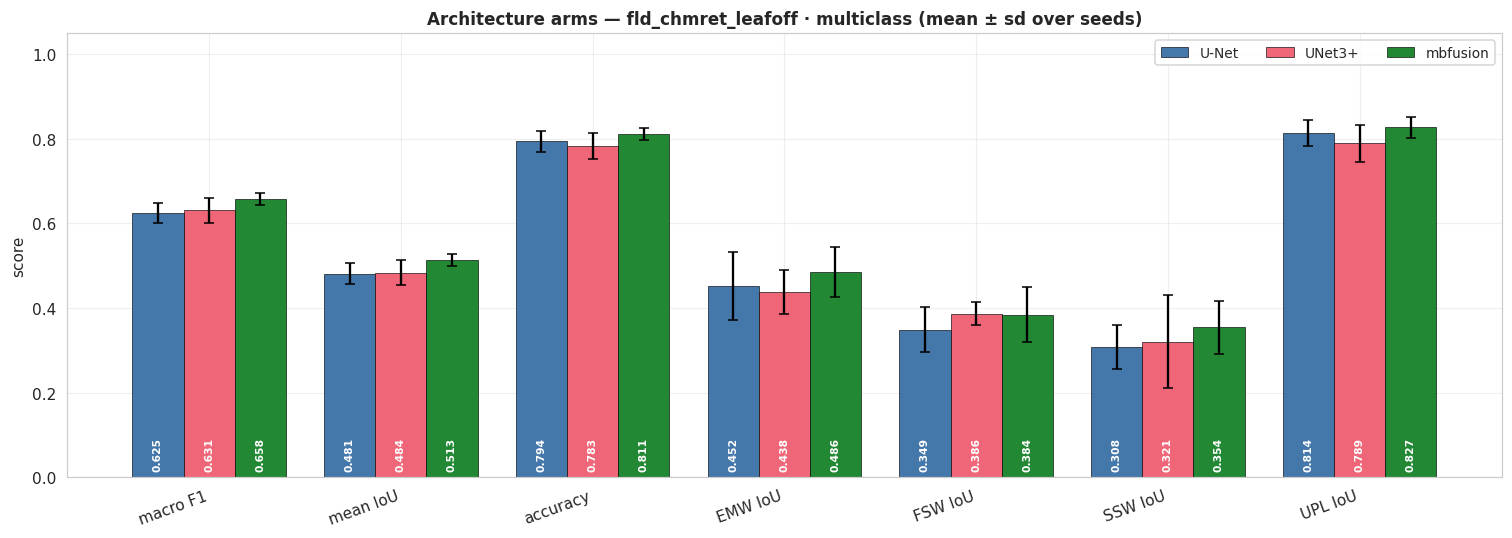

          macro_f1         mean_iou         overall_accuracy         iou_EMW         iou_FSW         iou_SSW         iou_UPL        
              mean     std     mean     std             mean     std    mean     std    mean     std    mean     std    mean     std
arch                                                                                                                                
mbfusion    0.6576  0.0133   0.5128  0.0146           0.8114  0.0133  0.4855  0.0591  0.3843  0.0648  0.3541  0.0624  0.8273  0.0249
unet        0.6251  0.0241   0.4806  0.0250           0.7944  0.0252  0.4520  0.0813  0.3490  0.0542  0.3077  0.0509  0.8137  0.0301
unet3plus   0.6308  0.0295   0.4836  0.0295           0.7827  0.0310  0.4383  0.0522  0.3861  0.0274  0.3207  0.1102  0.7893  0.0437


In [19]:
# Grouped bars over N arms (not two): one group per metric, one bar per arm.
if archl.empty:
    print("arch bars: no arms - skipping.")
else:
    _metrics = [m for m in ["macro_f1", "mean_iou", "overall_accuracy"]
                + [f"iou_{c}" for c in CLASS_ORDER] if m in archl]
    _labels = [{"macro_f1": "macro F1", "mean_iou": "mean IoU",
                "overall_accuracy": "accuracy"}.get(m, f"{m[4:]} IoU") for m in _metrics]
    agg = archl.groupby("arch")[_metrics].agg(["mean", "std"])

    x = np.arange(len(_metrics)); n = len(ARCH_PRESENT); w = 0.8 / n
    fig, ax = plt.subplots(figsize=(1.55 * len(_metrics) + 3, 5))
    for j, arm in enumerate(ARCH_PRESENT):
        off = (j - (n - 1) / 2) * w
        mu = [agg.loc[arm, (m, "mean")] for m in _metrics]
        sd = [np.nan_to_num(agg.loc[arm, (m, "std")]) for m in _metrics]
        ax.bar(x + off, mu, w, yerr=sd, capsize=3, color=ARCH_COLORS.get(arm),
               edgecolor="black", linewidth=0.4, label=ARCH_LABEL.get(arm, arm))
        # Value labels sit INSIDE the bar: above it they collide with the sd whisker.
        for xi, v in zip(x + off, mu):
            ax.text(xi, 0.015, f"{v:.3f}", ha="center", va="bottom", rotation=90,
                    fontsize=7, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(_labels, rotation=20, ha="right")
    ax.set_ylabel("score"); ax.set_ylim(0, 1.05)
    ax.set_title(f"Architecture arms — {ARCH_CFG} · {MODE_LEVEL or 'multiclass'} "
                 f"(mean ± sd over seeds)")
    ax.legend(ncol=n, loc="upper right", fontsize=9)
    fig.tight_layout(); savefig(fig, "07a_arch_bars"); plt.show()

    print(agg.round(4).to_string())

### 7b · Paired-seed deltas — the credible summary at n=5

Every arm minus the baseline **on the same seed**, so each dot is a paired
difference on an identical test set. The diamond is the mean; the number on the
right is how many seeds the arm won. **A consistent 5/5 with a small delta beats
a large delta that flips sign** — that is the whole reading at this n.

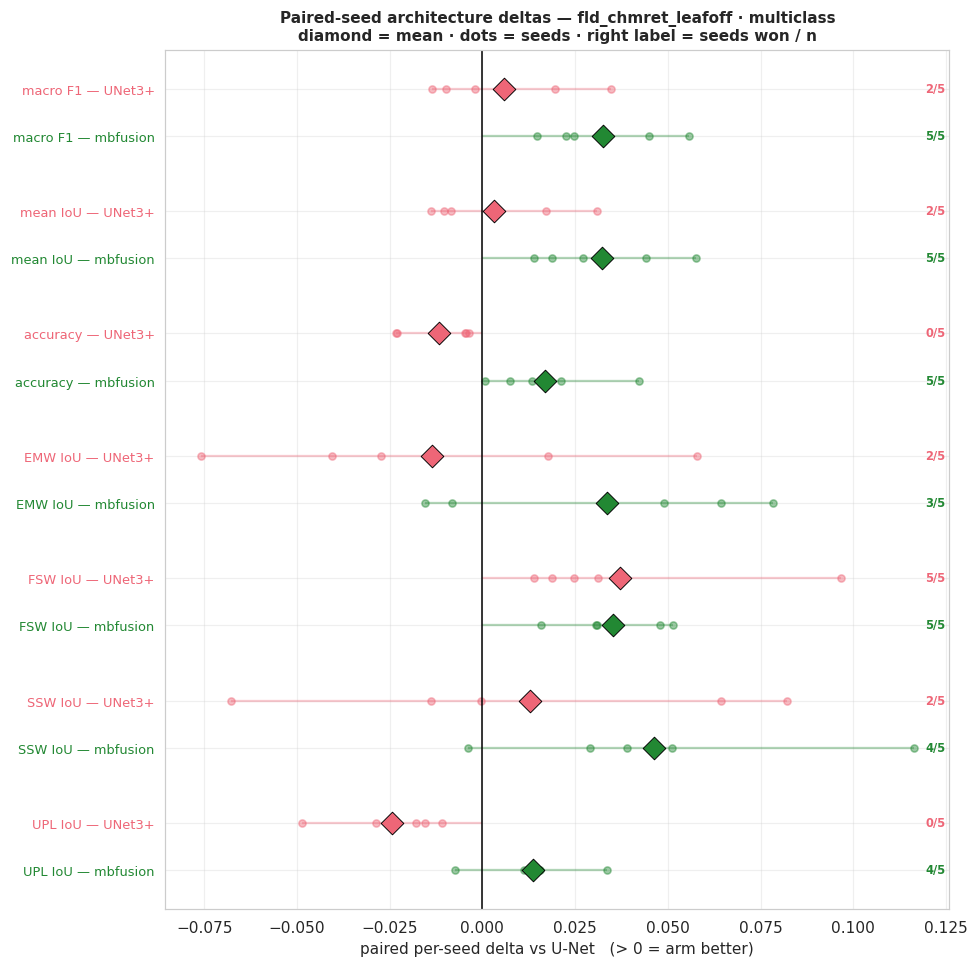

paired deltas vs unet (same seed => same test patches):
     arch           metric  baseline_mean  arch_mean  delta_mean  delta_sd  n_better  n_seeds  sign_consistent
unet3plus         macro_f1         0.6251     0.6308      0.0058    0.0206         2        5            False
unet3plus         mean_iou         0.4806     0.4836      0.0030    0.0198         2        5            False
unet3plus overall_accuracy         0.7944     0.7827     -0.0117    0.0104         0        5             True
unet3plus          iou_EMW         0.4520     0.4383     -0.0137    0.0521         2        5            False
unet3plus          iou_FSW         0.3490     0.3861      0.0370    0.0340         5        5             True
unet3plus          iou_SSW         0.3077     0.3207      0.0130    0.0609         2        5            False
unet3plus          iou_UPL         0.8137     0.7893     -0.0243    0.0151         0        5             True
 mbfusion         macro_f1         0.6251     0.6576    

In [20]:
# Paired per-seed deltas vs the baseline arm. Mirrors arch_contrasts.csv.
_OTHERS = [a for a in ARCH_PRESENT if a != ARCH_BASELINE]
if archl.empty or not _OTHERS:
    print("arch deltas: need a baseline plus at least one other arm - skipping.")
else:
    _dm = [m for m in ["macro_f1", "mean_iou", "overall_accuracy"]
           + [f"iou_{c}" for c in CLASS_ORDER] if m in archl]
    _nice = {"macro_f1": "macro F1", "mean_iou": "mean IoU",
             "overall_accuracy": "accuracy"}
    base = archl[archl["arch"] == ARCH_BASELINE].set_index("seed")

    fig, ax = plt.subplots(figsize=(9, 0.45 * len(_dm) * len(_OTHERS) + 2.6))
    ticks, ticklabels, tickcolors, row = [], [], [], 0
    for m in _dm:
        for arm in _OTHERS:
            a = archl[archl["arch"] == arm].set_index("seed")
            shared = sorted(set(base.index) & set(a.index))
            d = (a.loc[shared, m] - base.loc[shared, m]).dropna()
            if d.empty:
                row += 1
                continue
            c = ARCH_COLORS.get(arm)
            ax.hlines(row, min(0, d.min()), max(0, d.max()), color=c, alpha=0.35, zorder=1)
            ax.scatter(d.values, [row] * len(d), s=22, color=c, alpha=0.45, zorder=2)
            ax.scatter([d.mean()], [row], s=110, marker="D", color=c,
                       edgecolor="black", linewidth=0.6, zorder=3)
            ax.text(0.995, row, f"{int((d > 0).sum())}/{len(d)}",
                    transform=ax.get_yaxis_transform(), ha="right", va="center",
                    fontsize=7.5, color=c, fontweight="bold")
            ticks.append(row)
            ticklabels.append(f"{_nice.get(m, m[4:] + ' IoU')} — {ARCH_LABEL.get(arm, arm)}")
            tickcolors.append(c)
            row += 1
        row += 0.6                      # blank gutter between metrics
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(ticks); ax.set_yticklabels(ticklabels, fontsize=8.5); ax.invert_yaxis()
    # The tick label already names the arm, so color it instead of adding a
    # legend -- a legend box here lands on top of the widest row's dots.
    for _t, _c in zip(ax.get_yticklabels(), tickcolors):
        _t.set_color(_c)
    ax.set_xlabel(f"paired per-seed delta vs {ARCH_LABEL.get(ARCH_BASELINE, ARCH_BASELINE)}"
                  "   (> 0 = arm better)")
    ax.set_title(f"Paired-seed architecture deltas — {ARCH_CFG} · {MODE_LEVEL or 'multiclass'}\n"
                 "diamond = mean · dots = seeds · right label = seeds won / n", fontsize=10)
    fig.tight_layout(); savefig(fig, "07b_arch_deltas"); plt.show()

    if not arch_contrasts.empty:
        _show = arch_contrasts[arch_contrasts["metric"].isin(_dm)]
        print(f"paired deltas vs {ARCH_BASELINE} (same seed => same test patches):")
        print(_show[["arch", "metric", "baseline_mean", "arch_mean", "delta_mean",
                     "delta_sd", "n_better", "n_seeds", "sign_consistent"]]
              .round(4).to_string(index=False))

### 7c · Directional FSW ↔ UPL confusion — the failure mbfusion targets

Forested wetland lost to upland is *the* error mode of this task: closed-canopy
FSW looks like upland forest in leaf-on NAIP, and only the LiDAR structure and
terrain channels separate them. Giving each modality its own encoder is meant to
stop the spectral branch from swamping that signal, so this is the contrast the
fusion arm has to win.

Rates are **row-normalized** — `true FSW → pred UPL` is the share of true-FSW
pixels called UPL — so they are comparable across cells regardless of prevalence.
**Lower is better** here, which the contrast table's `n_better` already accounts
for (`lower_is_better = True`). Multiclass only; binary has no FSW.

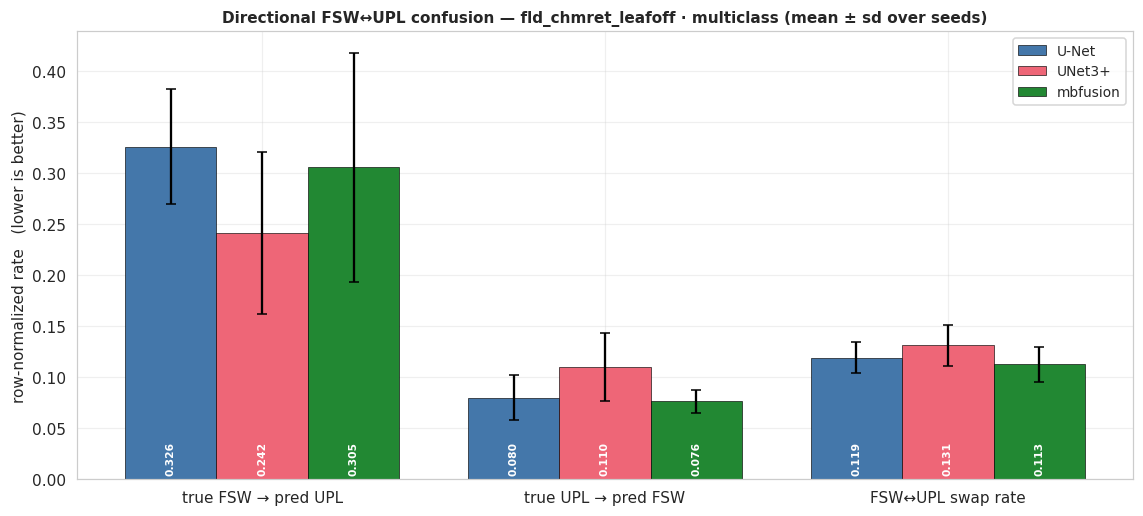

n_better counts seeds where the rate DROPPED (lower_is_better):
     arch            metric  baseline_mean  arch_mean  delta_mean  n_better  n_seeds  sign_consistent
unet3plus   conf_FSW_as_UPL         0.3258     0.2415     -0.0843         5        5             True
unet3plus   conf_UPL_as_FSW         0.0800     0.1101      0.0301         0        5             True
unet3plus conf_FSW_UPL_swap         0.1192     0.1310      0.0119         0        5             True
 mbfusion   conf_FSW_as_UPL         0.3258     0.3053     -0.0205         4        5            False
 mbfusion   conf_UPL_as_FSW         0.0800     0.0763     -0.0036         4        5            False
 mbfusion conf_FSW_UPL_swap         0.1192     0.1128     -0.0064         3        5            False


In [21]:
# Row-normalized directional confusion for the CONF_PAIR classes, per arm.
_conf_cols = [c for c in archl.columns if c.startswith("conf_")] if not archl.empty else []
if not _conf_cols:
    print(f"confusion pair: nothing to plot (pair={CONF_PAIR}, "
          f"mode={MODE_LEVEL or 'multiclass'}) - skipping.")
else:
    _a, _b = CONF_PAIR
    _order = [c for c in (f"conf_{_a}_as_{_b}", f"conf_{_b}_as_{_a}",
                          f"conf_{_a}_{_b}_swap") if c in _conf_cols]
    _pretty = {f"conf_{_a}_as_{_b}": f"true {_a} → pred {_b}",
               f"conf_{_b}_as_{_a}": f"true {_b} → pred {_a}",
               f"conf_{_a}_{_b}_swap": f"{_a}↔{_b} swap rate"}
    agg = archl.groupby("arch")[_order].agg(["mean", "std"])

    x = np.arange(len(_order)); n = len(ARCH_PRESENT); w = 0.8 / n
    fig, ax = plt.subplots(figsize=(3.0 * len(_order) + 1.5, 4.8))
    for j, arm in enumerate(ARCH_PRESENT):
        off = (j - (n - 1) / 2) * w
        mu = [agg.loc[arm, (c, "mean")] for c in _order]
        sd = [np.nan_to_num(agg.loc[arm, (c, "std")]) for c in _order]
        ax.bar(x + off, mu, w, yerr=sd, capsize=3, color=ARCH_COLORS.get(arm),
               edgecolor="black", linewidth=0.4, label=ARCH_LABEL.get(arm, arm))
        for xi, v in zip(x + off, mu):
            ax.text(xi, 0.004, f"{v:.3f}", ha="center", va="bottom", rotation=90,
                    fontsize=7, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels([_pretty[c] for c in _order])
    ax.set_ylabel("row-normalized rate   (lower is better)")
    ax.set_title(f"Directional {_a}↔{_b} confusion — {ARCH_CFG} · "
                 f"{MODE_LEVEL or 'multiclass'} (mean ± sd over seeds)", fontsize=10)
    ax.legend(fontsize=9)
    fig.tight_layout(); savefig(fig, "07c_arch_confusion_pair"); plt.show()

    if not arch_contrasts.empty:
        _cc = arch_contrasts[arch_contrasts["metric"].isin(_order)]
        print("n_better counts seeds where the rate DROPPED (lower_is_better):")
        print(_cc[["arch", "metric", "baseline_mean", "arch_mean", "delta_mean",
                   "n_better", "n_seeds", "sign_consistent"]].round(4).to_string(index=False))

### 7d · Cost — is the accuracy worth the compute?

Params come from the trainer's journal (exact) with the `.safetensors` header
and `train.log` as fallbacks; **GFLOPs exist only in `train.log`**, so a
`--metrics-only` pull that dropped the logs shows NaN there. Timing is
wall-clock on the run's own GPU and batch size (mbfusion runs at `BATCH_SIZE=8`,
the base grid at 16) — read it as an order of magnitude, not a benchmark.
`epochs_run` < 50 means early stopping fired.

                params  gflops  sec_per_epoch  epochs_run  fit_seconds  params_x_baseline
arch                                                                                     
unet       125266628.0   122.0         13.080        47.6       624.54              1.000
unet3plus   99797528.0   533.0         22.000        31.6       695.92              0.797
mbfusion   162012860.0   143.0         13.324        43.6       580.56              1.293


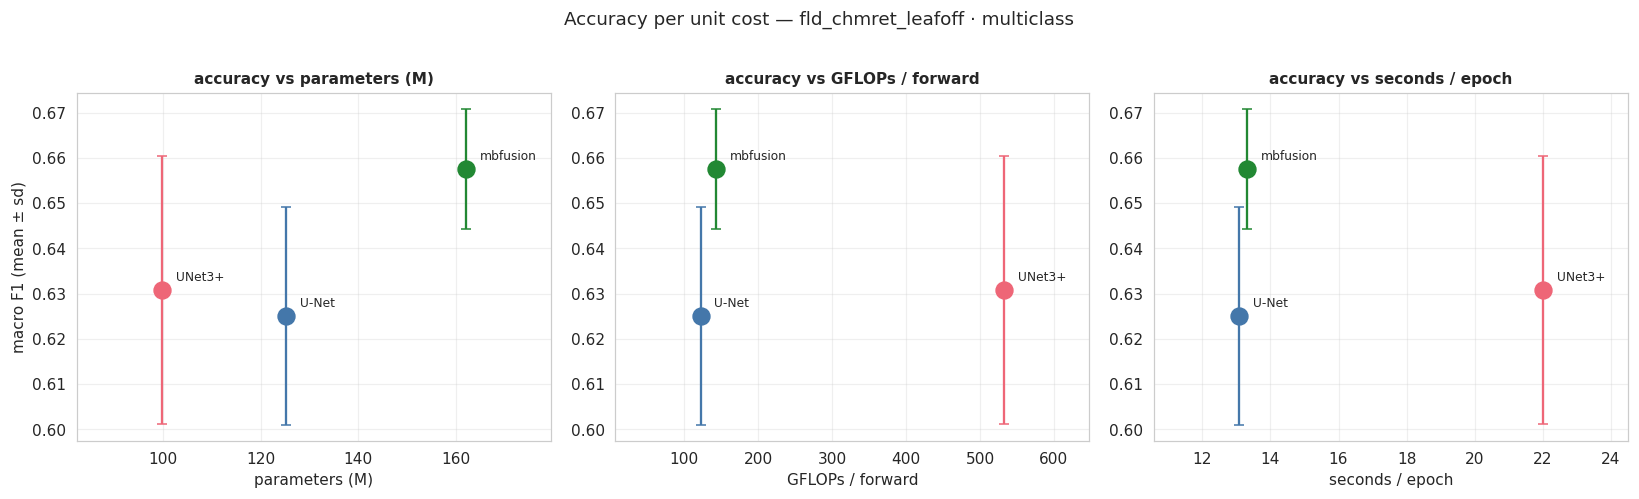

In [22]:
# Cost table + accuracy-per-unit-cost scatter. Mirrors arch_cost.csv.
if archl.empty:
    print("arch cost: no arms - skipping.")
else:
    _COST = [c for c in _agg.COST_COLS if c in archl]
    cost = archl.groupby("arch")[_COST].mean().reindex(ARCH_PRESENT)
    if "params" in cost and cost.loc[ARCH_BASELINE, "params"]:
        cost["params_x_baseline"] = cost["params"] / cost.loc[ARCH_BASELINE, "params"]
    acc = (archl.groupby("arch")[["macro_f1", "mean_iou"]]
                .agg(["mean", "std"]).reindex(ARCH_PRESENT))
    print(cost.round(3).to_string())

    _panels = [("params", "parameters (M)", 1e6), ("gflops", "GFLOPs / forward", 1),
               ("sec_per_epoch", "seconds / epoch", 1)]
    _panels = [p for p in _panels if p[0] in cost and not cost[p[0]].isna().all()]
    if not _panels:
        print("\nno cost columns recovered (train.log / training_log.json missing?) - "
              "skipping the cost scatter.")
    else:
        fig, axes = plt.subplots(1, len(_panels), figsize=(5.0 * len(_panels), 4.4),
                                 squeeze=False)
        for k, (ax, (col, xlabel, scale)) in enumerate(zip(axes[0], _panels)):
            for arm in ARCH_PRESENT:
                xv = cost.loc[arm, col] / scale
                ax.errorbar(xv, acc.loc[arm, ("macro_f1", "mean")],
                            yerr=np.nan_to_num(acc.loc[arm, ("macro_f1", "std")]),
                            marker="o", markersize=11, capsize=3, linestyle="",
                            color=ARCH_COLORS.get(arm), label=ARCH_LABEL.get(arm, arm))
                ax.annotate(ARCH_LABEL.get(arm, arm),
                            (xv, acc.loc[arm, ("macro_f1", "mean")]),
                            textcoords="offset points", xytext=(9, 6), fontsize=8)
            ax.margins(x=0.28)          # room for the point labels at the edges
            ax.set_xlabel(xlabel)
            ax.set_ylabel("macro F1 (mean ± sd)" if k == 0 else "")
            ax.set_title(f"accuracy vs {xlabel}", fontsize=10)
        fig.suptitle(f"Accuracy per unit cost — {ARCH_CFG} · {MODE_LEVEL or 'multiclass'}",
                     y=1.02)
        fig.tight_layout(); savefig(fig, "07d_arch_cost"); plt.show()

### 7e · Validation curves

Per-epoch validation from each cell's `training_history_*.json`, one
representative seed. Curves end where early stopping fired, so a short curve is
a fast converger, not a truncated run. Compare *shape* — how fast each arm gets
there and whether it is still climbing — rather than the final point, which 7a
already reports on the held-out test set.

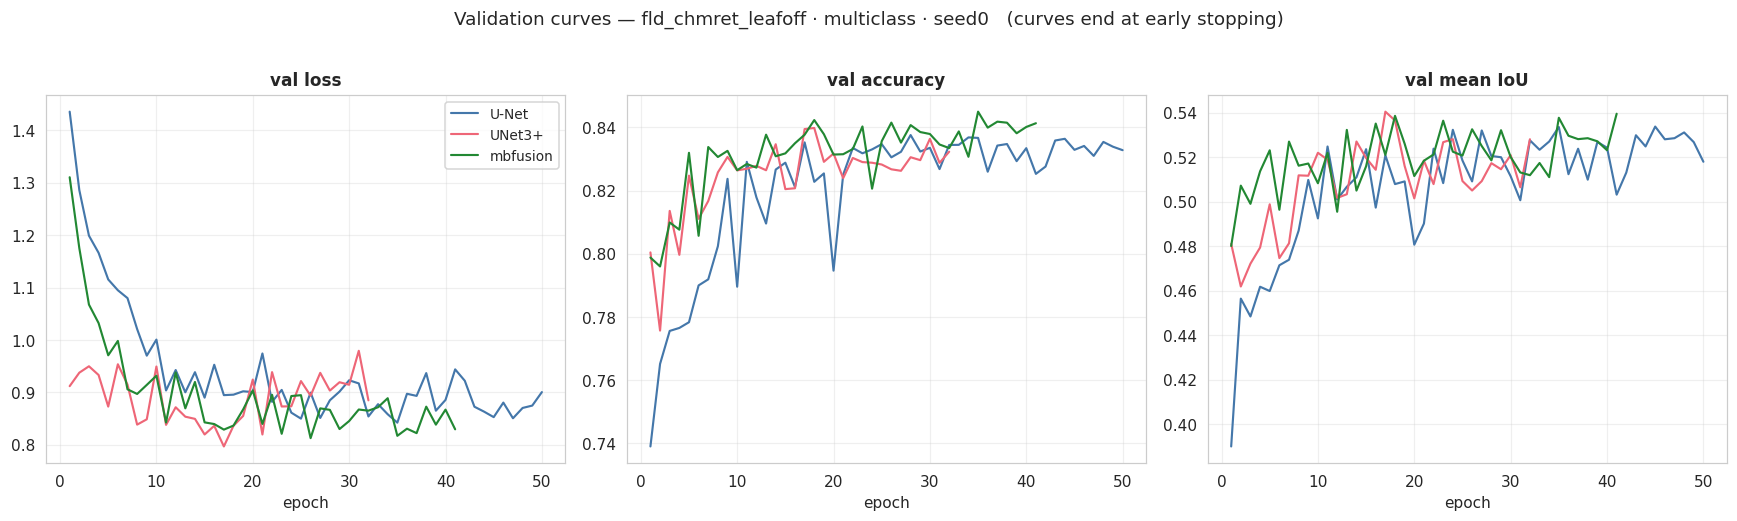

epochs run: {'unet': 50, 'unet3plus': 32, 'mbfusion': 41}


In [23]:
# Per-epoch validation curves, all arms, one seed.
ARCH_SEED = 0

def load_history(cell_dir, seed):
    """training_history_<mode>_<arch>.json, written per cell by the trainer."""
    hits = sorted(Path(cell_dir).glob(f"seed{seed}/training_history_*.json"))
    return json.loads(hits[0].read_text()) if hits else None

_hists = {a: load_history(c, ARCH_SEED) for a, c in ARCH_CELLS.items()}
_hists = {a: h for a, h in _hists.items() if h}
if not _hists:
    print(f"arch val-curves: no training_history for seed{ARCH_SEED} - skipping.")
else:
    _panels = [("val_loss", "val loss"), ("val_accuracy", "val accuracy"),
               ("val_iou", "val mean IoU")]
    fig, axes = plt.subplots(1, len(_panels), figsize=(5.3 * len(_panels), 4.6))
    for k, (ax, (key, title)) in enumerate(zip(axes, _panels)):
        for arm in ARCH_PRESENT:
            y = (_hists.get(arm) or {}).get(key, [])
            if y:
                ax.plot(range(1, len(y) + 1), y, color=ARCH_COLORS.get(arm),
                        linewidth=1.4, label=ARCH_LABEL.get(arm, arm))
        ax.set_xlabel("epoch"); ax.set_title(title)
        if k == 0:
            ax.legend(fontsize=9)
    fig.suptitle(f"Validation curves — {ARCH_CFG} · {MODE_LEVEL or 'multiclass'} · "
                 f"seed{ARCH_SEED}   (curves end at early stopping)", y=1.02, fontsize=12)
    fig.tight_layout(); savefig(fig, "07e_arch_val_curves"); plt.show()

    print("epochs run:", {a: len(h.get("val_loss", [])) for a, h in _hists.items()})

### 7f · Inside the fusion gate — which modality does the model trust, and where?

#### The idea in plain terms: a committee of four specialists

At every location on the map, `mbfusion` consults four specialists, each looking
at the same spot of ground with a different instrument:

| specialist | what it looks at |
|---|---|
| **terrain** | the shape of the ground — slopes, hollows, how water would flow |
| **lidar** | how tall and dense the vegetation is |
| **leafon** | the summer photo, canopy in full leaf |
| **leafoff** | the spring photo, bare branches, ground visible |

The **gate** is the thing that decides how much to trust each of them. Think of
it as handing out **100 trust points among the four, separately at every
location**. A wet hollow with bare ground showing might give leaf-off 60 points.
A dense closed canopy, where both photos are useless, might split 80 between
lidar and terrain. The points always add to 100 — that is all the "softmax
across branches" in the code means.

It does this **six times over, at six zoom levels**, from a 1 m spot up to a
32 m block, and the allocations are free to differ between them. Every figure in
7f is a different way of reading those allocations.

#### Where the numbers come from

`dl_11_export_gates.py` has already saved the allocations for 8 held-out field
patches per cell: `<cell>/seed<k>/gates/<patch>.npz`, keys `level0` (256²) …
`level5` (8²), each `(4, H, W)` float16, plus `gate_summary.json`. Nothing here
re-runs the model — 7f only reads those files.

#### The one rule every figure below obeys

Handing out trust points is only half of what the model does. **After** the
split, it still rescales each specialist's contribution on the way to the answer
(`proj` is a 1×1 conv, so the decoder sees `Σ Wᵢ(fᵢ·gᵢ)`; GroupNorm equalizes
the *features*, not those weights). A specialist with modest trust points but a
loud voice can still dominate. So:

- **Valid:** following *one* specialist across space — "terrain is trusted more
  in the hollows than on the sideslopes". Only the gate varies, so the pattern
  is real.
- **Not valid:** "terrain matters more than lidar overall." For that, use
  **SHAP (§4)**, which measures effect on the output rather than attention.

That is why every map here is **standardized within a specialist**, and why the
one figure showing all four together (the argmax mosaic) reports *who won* — a
choice — rather than how much anyone got.

#### Two sampling facts that limit what can be claimed

The exported patches are each seed's own held-out test split, so **no patch is
shared by all five seeds** (37 distinct patches across 5×8 slots) — any
cross-seed number mixes the seed effect with which patches it happened to get.
And with only 8 patches, a seed can miss a rare class entirely. Both are why
7f-4 plots per-seed points instead of one pooled average.

In [24]:
# --- 7f setup: locate the fusion cells and profile every exported gate -------
# Self-contained: rebuilds its own paths rather than depending on the §7 setup
# cell, so 7f can be run on its own. Only the notebook-wide Setup cell is needed.
GATE_CFG  = globals().get("ARCH_CFG", "fld_chmret_leafoff")
GATE_ROOT = with_mode(MODELS_DIR / f"results_arch_fusion{_SUFFIX}")
# Branch colors are a different axis from the arch colors used in 7a-7e.
BRANCH_COLORS = {"terrain": "#8c6d31", "lidar": "#2b8c4a",
                 "leafon": "#3182bd", "leafoff": "#c9662c"}

_cands = sorted(GATE_ROOT.glob(f"{GATE_CFG}_mbfusion/seed*")) if GATE_ROOT.is_dir() else []
GATE_CELLS = {int(p.name[4:]): p for p in _cands
              if p.name[4:].isdigit() and (p / "gates/gate_summary.json").exists()}
print(f"gate root : {GATE_ROOT}")
print(f"cells with gates: {sorted(GATE_CELLS)}" if GATE_CELLS else "NO exported gates found")

# Profile every seed x level: entropy, hard-selection rate, per-branch mean and
# argmax share, plus the within-branch (mean, sd) used to standardize the maps.
GATE_BRANCHES, GATE_LEVELS, GATE_NORM = [], [], {}
_prof, _bprof = [], []
for seed, cell in GATE_CELLS.items():
    summ = json.loads((cell / "gates/gate_summary.json").read_text())
    branches = list(summ["branches"])
    files = sorted((cell / "gates").glob("*.npz"))
    if not files:
        continue
    levels = sorted(int(k[5:]) for k in np.load(files[0]).files if k.startswith("level"))
    GATE_BRANCHES, GATE_LEVELS = branches, levels
    for lv in levels:
        # (n_patch*H*W, n_branch) -- 8 patches of 4x256x256 float16 is ~4 MB.
        A = np.concatenate([np.load(f)[f"level{lv}"].astype(np.float32)
                            .reshape(len(branches), -1).T for f in files])
        p = np.clip(A, 1e-8, 1.0)
        ent = float(-(p * np.log(p)).sum(axis=1).mean())
        mx, am = A.max(axis=1), A.argmax(axis=1)
        _prof.append(dict(seed=seed, level=lv, entropy=ent,
                          frac_gt50=float((mx > 0.5).mean()),
                          frac_gt90=float((mx > 0.9).mean()),
                          frac_gt99=float((mx > 0.99).mean()),
                          n_pixels=int(A.shape[0])))
        for bi, b in enumerate(branches):
            mu, sd = float(A[:, bi].mean()), float(A[:, bi].std())
            GATE_NORM[(seed, lv, b)] = (mu, sd if sd > 0 else 1.0)
            _bprof.append(dict(seed=seed, level=lv, branch=b, mean_gate=mu,
                               sd_gate=sd, argmax_share=float((am == bi).mean())))

gate_prof   = pd.DataFrame(_prof)
gate_branch = pd.DataFrame(_bprof)
GATE_MAX_ENT = float(np.log(len(GATE_BRANCHES))) if GATE_BRANCHES else np.nan

if gate_prof.empty:
    print("\nNo gate .npz found - 7f will skip. Export them with dl_11_export_gates.py.")
else:
    print(f"branches  : {GATE_BRANCHES}   (max entropy = log {len(GATE_BRANCHES)} "
          f"= {GATE_MAX_ENT:.3f} nats)")
    print(f"levels    : {GATE_LEVELS}")
    print("\nentropy and hard-selection rate, mean over seeds:")
    print(gate_prof.groupby("level")[["entropy", "frac_gt50", "frac_gt90", "frac_gt99"]]
                   .mean().round(3).to_string())

gate root : /local/workdir/ajs544/nys_wetlands/Models/results_arch_fusion_v3/multiclass
cells with gates: [0, 1, 2, 3, 4]
branches  : ['terrain', 'lidar', 'leafon', 'leafoff']   (max entropy = log 4 = 1.386 nats)
levels    : [0, 1, 2, 3, 4, 5]

entropy and hard-selection rate, mean over seeds:
       entropy  frac_gt50  frac_gt90  frac_gt99
level                                          
0        1.201      0.347      0.003      0.000
1        1.009      0.588      0.045      0.000
2        0.500      0.927      0.423      0.117
3        0.198      0.985      0.753      0.559
4        0.128      0.990      0.842      0.702
5        0.039      0.999      0.947      0.897


#### 7f-1 · Soft blending at fine scale, hard switching at coarse scale

**What entropy is measuring.** Entropy reads one thing off the trust-point split
described above: **how evenly the 100 points were shared out** — how *decisive*
the committee was at that location. Nothing more.

| trust split | entropy | reads as |
|---|---|---|
| 25 / 25 / 25 / 25 | **1.386** (the ceiling, `log 4`) | "not sure — weigh everyone equally" |
| 70 / 10 / 10 / 10 | 0.94 | "mostly one opinion, others still in the room" |
| 98 / 1 / 1 / 1 | **≈ 0** | "one specialist decides, ignore the rest" |

**It does not record *who* got the points.** A location where terrain took 98 and
one where leaf-off took 98 have exactly the same entropy. It measures
decisiveness, never preference — which is also why there is no such thing as
"the lidar branch's entropy": there is one value per location, shared by the
whole committee, the way turnout describes an election rather than any one voter.

**Why it falls as you zoom out.** The question changes with the zoom level. At
level 0 the model is asking *"is this one square metre wet?"* — nobody can answer
that alone, so it hedges (top specialist gets ~47 points, runner-up ~26). At
level 5 it is asking *"what kind of place is this 32 m stand?"* — often settled by
a single line of evidence, so it commits (top specialist gets ~98). It was never
told to do this; it is what fell out of training, and all five seeds did it the
same way, which is what makes this the trustworthy panel of the section.

**Why we watch it: the collapse check.** The failure to fear is one specialist
taking over permanently in the first few epochs, leaving three encoders trained
and never consulted — four models paid for, one used. That would look like
entropy pinned near zero *everywhere, from the start*. Telling that apart from
what actually happened needs both panels plus 7f-3: entropy does fall near zero
at coarse scales, **but** who wins varies from place to place and no specialist
takes more than ~43 % of the map at any level. All four are still earning their
keep, each in its own places.

**Entropy is a thermometer, not a thermostat.** It is only ever *logged*
(`dl_04_train_lightning.py:351`) — never added to the loss, and the gates it is
computed from are detached, so it cannot influence training even by accident. Had
it collapsed, the fix was a temperature knob on the gate, deliberately left
unbuilt rather than added speculatively (PLAN §6.6).

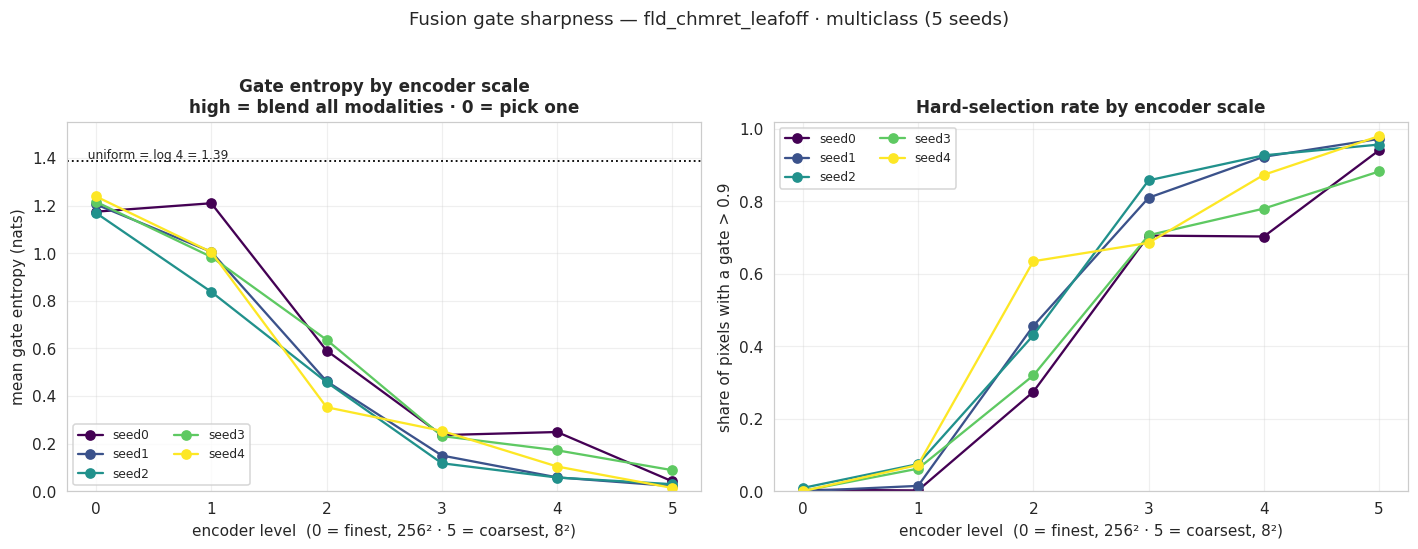

seed       0      1      2      3      4
level                                   
0      1.175  1.205  1.169  1.216  1.239
1      1.210  1.006  0.838  0.985  1.005
2      0.591  0.462  0.458  0.636  0.353
3      0.236  0.150  0.117  0.232  0.253
4      0.249  0.058  0.057  0.172  0.104
5      0.041  0.022  0.029  0.088  0.014


In [26]:
# Entropy and hard-selection rate vs encoder scale, one line per seed.
if gate_prof.empty:
    print("7f-1: no gate profile - skipping.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    _seeds = sorted(gate_prof["seed"].unique())
    _cmap = plt.get_cmap("viridis")
    for i, s in enumerate(_seeds):
        d = gate_prof[gate_prof["seed"] == s].sort_values("level")
        c = _cmap(i / max(len(_seeds) - 1, 1))
        axes[0].plot(d["level"], d["entropy"], marker="o", color=c, label=f"seed{s}")
        axes[1].plot(d["level"], d["frac_gt90"], marker="o", color=c, label=f"seed{s}")
    axes[0].axhline(GATE_MAX_ENT, color="black", linestyle=":", linewidth=1.2)
    axes[0].text(0.02, GATE_MAX_ENT, f"  uniform = log {len(GATE_BRANCHES)} "
                 f"= {GATE_MAX_ENT:.2f}", transform=axes[0].get_yaxis_transform(),
                 va="bottom", fontsize=8)
    axes[0].set_ylim(0, GATE_MAX_ENT * 1.12)
    axes[0].set_ylabel("mean gate entropy (nats)")
    axes[0].set_title("Gate entropy by encoder scale\nhigh = blend all modalities · 0 = pick one")
    axes[1].set_ylim(0, 1.02)
    axes[1].set_ylabel("share of pixels with a gate > 0.9")
    axes[1].set_title("Hard-selection rate by encoder scale")
    for ax in axes:
        ax.set_xlabel("encoder level  (0 = finest, 256² · 5 = coarsest, 8²)")
        ax.set_xticks(GATE_LEVELS); ax.legend(fontsize=8, ncol=2)
    fig.suptitle(f"Fusion gate sharpness — {GATE_CFG} · {MODE_LEVEL or 'multiclass'} "
                 f"({len(_seeds)} seeds)", y=1.03)
    fig.tight_layout(); savefig(fig, "07f1_gate_entropy_profile"); plt.show()

    print(gate_prof.pivot_table(index="level", columns="seed",
                                values="entropy").round(3).to_string())

#### 7f-2 · Where each modality is trusted — gate maps, standardized within branch

One patch, branches × the scales where a map is still legible. Each panel is
**z-scored against that branch's own mean and sd over all 8 exported patches at
that level**, so red = "this branch is trusted here more than it usually is" and
blue = less. That within-branch standardization is what makes the comparison
valid — on a shared 0–1 scale a low-mean branch looks empty everywhere and the
panel says nothing.

Because each panel has its own reference, **do not read across columns**: a red
patch under `terrain` and a red patch under `lidar` are each relative to their
own branch, not to each other.

seed0 patch: LabO_cluster_208_huc_041402011005_patch_20_256m
available:
  LabO_cluster_208_huc_041402011005_patch_20_256m
  LabO_cluster_208_huc_041402011005_patch_21_256m
  LabO_cluster_208_huc_041402011005_patch_8_256m
  NHP_AJS_cluster_82_huc_042701010304_patch_10_256m
  NHP_AJS_cluster_82_huc_042701010304_patch_11_256m
  NHP_AJS_cluster_82_huc_042701010304_patch_12_256m
  NHP_AJS_cluster_82_huc_042701010304_patch_13_256m
  NHP_AJS_cluster_82_huc_042701010304_patch_14_256m


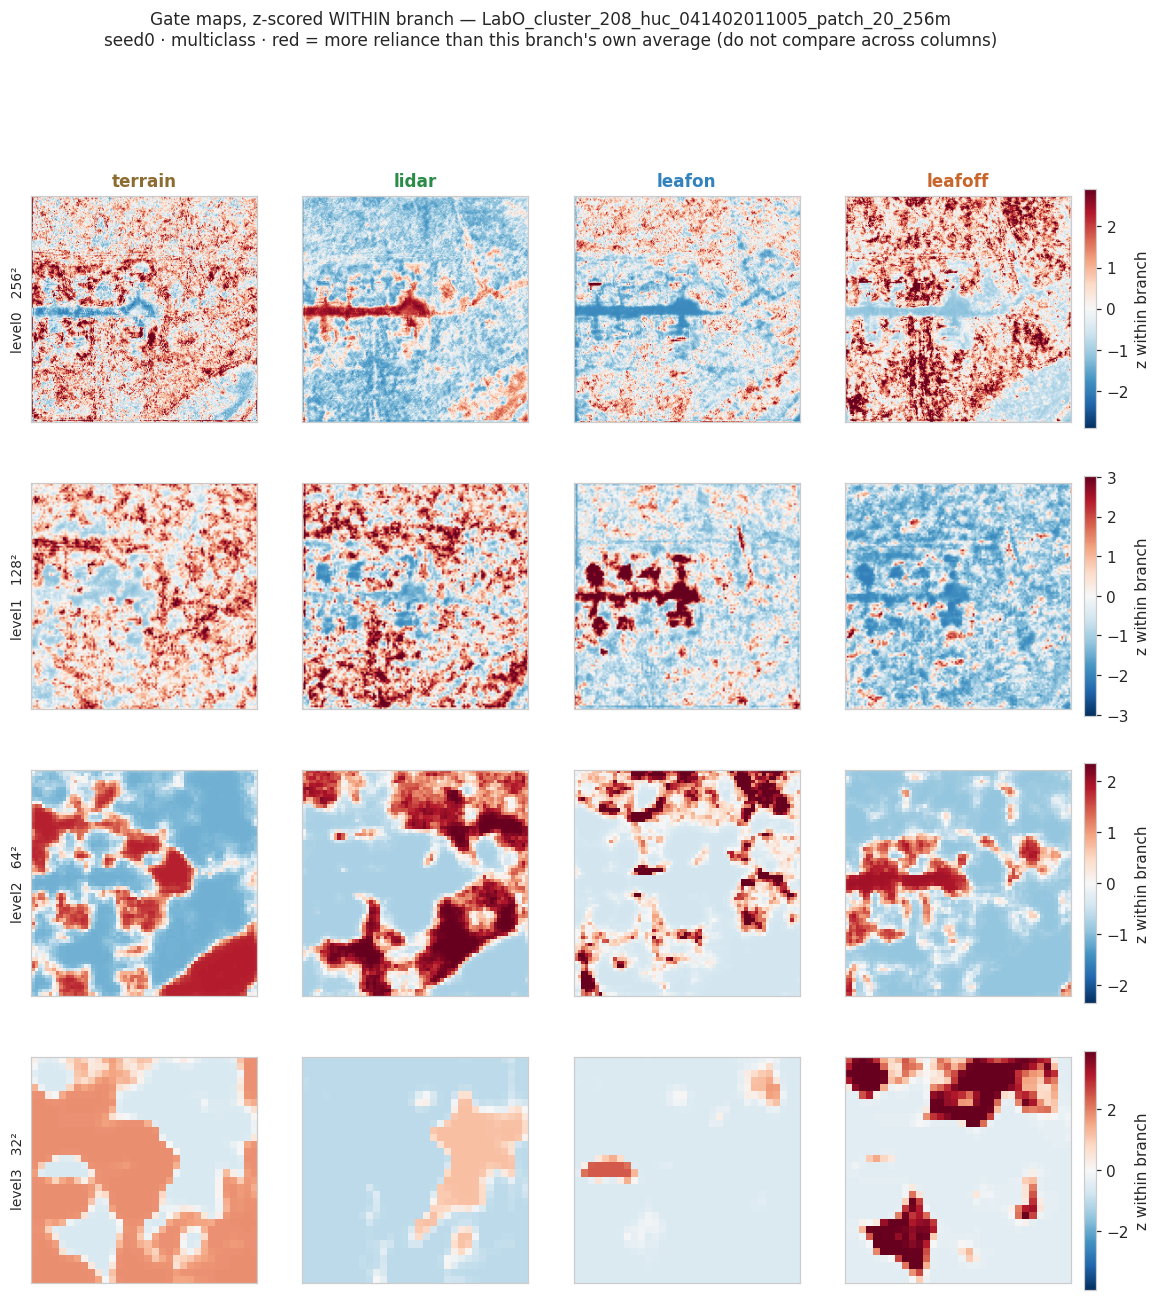

In [27]:
# Per-branch gate maps for one patch, z-scored within branch. Set GATE_PATCH to
# any stem printed below; None = the first exported patch for GATE_SEED.
GATE_SEED     = 0
GATE_PATCH    = None
GATE_MAP_LEVELS = [0, 1, 2, 3]        # 4+ are 16x16 / 8x8 -- see the mosaic instead

if not GATE_CELLS or GATE_SEED not in GATE_CELLS:
    print(f"7f-2: no gates for seed{GATE_SEED} (have {sorted(GATE_CELLS)}) - skipping.")
else:
    _gdir = GATE_CELLS[GATE_SEED] / "gates"
    _avail = sorted(p.stem for p in _gdir.glob("*.npz"))
    _stem = GATE_PATCH or _avail[0]
    print(f"seed{GATE_SEED} patch: {_stem}")
    print("available:", *[f"  {s}" for s in _avail], sep="\n")

    _d = np.load(_gdir / f"{_stem}.npz")
    _lv = [L for L in GATE_MAP_LEVELS if f"level{L}" in _d.files]
    fig, axes = plt.subplots(len(_lv), len(GATE_BRANCHES),
                             figsize=(3.15 * len(GATE_BRANCHES), 3.25 * len(_lv)),
                             squeeze=False)
    for r, L in enumerate(_lv):
        A = _d[f"level{L}"].astype(np.float32)
        Z = [(A[c] - GATE_NORM[(GATE_SEED, L, b)][0]) / GATE_NORM[(GATE_SEED, L, b)][1]
             for c, b in enumerate(GATE_BRANCHES)]
        # ONE symmetric limit for the whole row, from a robust quantile pooled
        # over its branches: 16 separate colorbars make even a within-branch
        # read across scales impossible. Each map is already z-scored against
        # its OWN branch, so a shared limit compares relative deviation, never
        # raw gate magnitude -- the comparison PLAN §6 rules out.
        lim = max(float(np.quantile(np.abs(np.stack(Z)), 0.98)), 1e-3)
        for c, b in enumerate(GATE_BRANCHES):
            ax = axes[r][c]
            im = ax.imshow(Z[c], cmap="RdBu_r", vmin=-lim, vmax=lim)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if r == 0:
                ax.set_title(b, color=BRANCH_COLORS.get(b, "black"), fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"level{L}   {A.shape[-1]}²", fontsize=9)
        fig.colorbar(im, ax=axes[r], fraction=0.020, pad=0.012,
                     label="z within branch")
    fig.suptitle(f"Gate maps, z-scored WITHIN branch — {_stem}\n"
                 f"seed{GATE_SEED} · {MODE_LEVEL or 'multiclass'} · "
                 "red = more reliance than this branch's own average "
                 "(do not compare across columns)", y=1.005, fontsize=11)
    savefig(fig, "07f2_gate_maps"); plt.show()

#### 7f-3 · The winning modality — argmax mosaic

Four continuous panels per scale is a lot to read, and at the coarse levels the
gate is already almost one-hot, so the continuous value carries little extra
information. This collapses each scale to **which branch won this pixel**, which
is a *choice* rather than a magnitude and therefore sidesteps the cross-branch
confound entirely.

The stacked bar is the same argmax pooled over all exported patches and seeds.
A single colour filling a whole level would be the collapse signature — the
thing to check before believing any of the fusion arm's numbers.

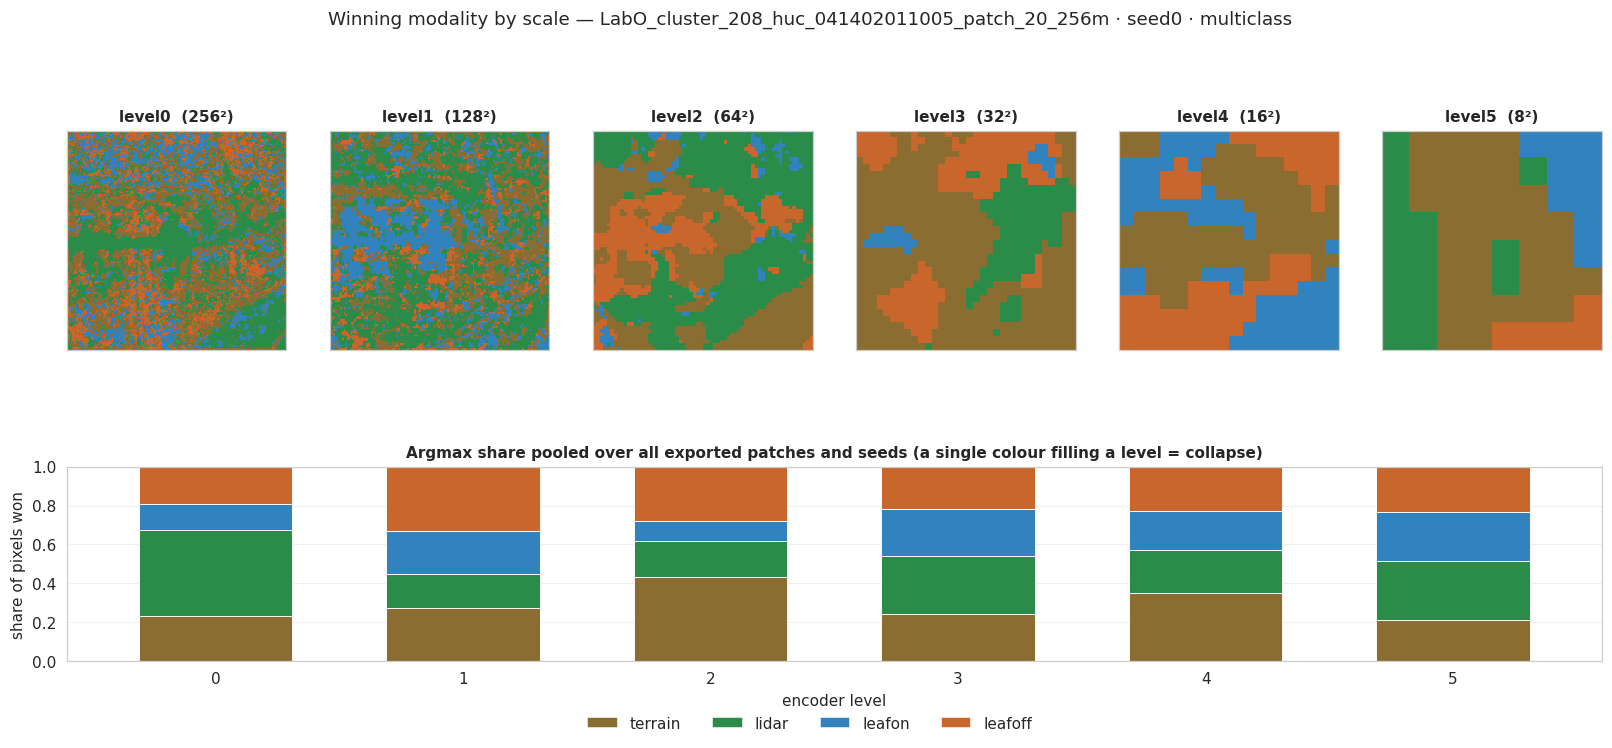

pooled argmax share by level:
branch  terrain  lidar  leafon  leafoff
level                                  
0         0.229  0.444   0.137    0.190
1         0.273  0.174   0.222    0.331
2         0.434  0.184   0.104    0.278
3         0.241  0.300   0.242    0.217
4         0.349  0.225   0.201    0.226
5         0.213  0.301   0.253    0.233


In [28]:
# Argmax "winning modality" mosaic for the same patch + pooled argmax shares.
if not GATE_CELLS or GATE_SEED not in GATE_CELLS:
    print("7f-3: no gates - skipping.")
else:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    _cmap_b = ListedColormap([BRANCH_COLORS.get(b, "#888888") for b in GATE_BRANCHES])
    _d = np.load(GATE_CELLS[GATE_SEED] / "gates" / f"{_stem}.npz")
    _all = [L for L in GATE_LEVELS if f"level{L}" in _d.files]

    fig = plt.figure(figsize=(3.0 * len(_all), 6.8))
    gs = fig.add_gridspec(2, len(_all), height_ratios=[1.6, 1.0], hspace=0.28)
    for i, L in enumerate(_all):
        A = _d[f"level{L}"].astype(np.float32)
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(A.argmax(axis=0), cmap=_cmap_b, vmin=-0.5,
                  vmax=len(GATE_BRANCHES) - 0.5, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f"level{L}  ({A.shape[-1]}²)", fontsize=10)
    # Bottom of the figure: anywhere between the two panels lands on a mosaic.
    fig.legend(handles=[Patch(facecolor=BRANCH_COLORS.get(b, "#888888"), label=b)
                        for b in GATE_BRANCHES],
               loc="upper center", bbox_to_anchor=(0.5, 0.055),
               ncol=len(GATE_BRANCHES), frameon=False, fontsize=10)

    # Pooled argmax share over every patch and seed -- the collapse check.
    ax = fig.add_subplot(gs[1, :])
    share = (gate_branch.groupby(["level", "branch"])["argmax_share"].mean()
                        .unstack()[GATE_BRANCHES])
    bottom = np.zeros(len(share))
    for b in GATE_BRANCHES:
        ax.bar(share.index, share[b], 0.62, bottom=bottom,
               color=BRANCH_COLORS.get(b), edgecolor="white", linewidth=0.6, label=b)
        bottom += share[b].to_numpy()
    ax.set_xticks(list(share.index)); ax.set_xlim(-0.6, len(share) - 0.4)
    ax.set_ylim(0, 1); ax.set_xlabel("encoder level")
    ax.set_ylabel("share of pixels won")
    ax.set_title("Argmax share pooled over all exported patches and seeds "
                 "(a single colour filling a level = collapse)", fontsize=10)
    fig.suptitle(f"Winning modality by scale — {_stem} · seed{GATE_SEED} · "
                 f"{MODE_LEVEL or 'multiclass'}", y=0.98, fontsize=12)
    savefig(fig, "07f3_gate_argmax_mosaic"); plt.show()

    print("pooled argmax share by level:")
    print(share.round(3).to_string())

#### 7f-4 · Does gate reliance track the true class? *(needs `rasterio`)*

The question that connects the gate to §7c's FSW→UPL story: **on true-FSW pixels,
does the model lean on structure (LiDAR, terrain) more than it usually does?**

`level0` gates are 256² — exactly patch resolution — so the join to `MOD_CLASS`
is direct. Coarser levels need the label downsampled, and rather than
majority-vote a mixed block this keeps only blocks that are **a single class
throughout** (still 72–79 % of blocks even at level 5) and drops the rest, so a
class boundary never contaminates the contrast.

Values are the same **within-branch z-score** as 7f-2, now averaged over the
pixels of one class: `+0.4` means "this branch's gate runs 0.4 sd above its own
average on pixels of this class". Because the seeds hold **disjoint** patch sets,
each seed is plotted as its own point and the number is sign consistency — the
same convention as 7b. Treat a 2/4 or 3/5 as noise.

This is the one cell that needs `rasterio` (to read `MOD_CLASS`). It self-skips
with a clear message if the kernel lacks it — use the `wetland-cnn` kernel.

In [29]:
# Class-conditional gate reliance. Needs rasterio to read the label band.
GATE_CLASS_LEVELS = [0, 2, 5]      # finest, the soft->hard transition, coarsest

try:
    import rasterio
    _HAVE_RIO = True
except ImportError as e:
    _HAVE_RIO = False
    print(f"7f-4 needs rasterio ({e}); run this notebook on the wetland-cnn kernel "
          f"(or `uv run --with rasterio`). Skipping.")

def _pure_block(lab, factor, ignore):
    """Downsample labels by `factor`, keeping only blocks of a single class.
    A mixed block becomes `ignore` and drops out -- never a majority vote."""
    if factor == 1:
        return lab.astype(np.int64)
    h = lab.shape[0] // factor
    b = (lab[:h * factor, :h * factor].reshape(h, factor, h, factor)
            .transpose(0, 2, 1, 3).reshape(h, h, -1))
    first = b[:, :, :1]
    return np.where((b == first).all(axis=2), first[:, :, 0], ignore).astype(np.int64)

def _read_labels(tif, label_band, remap, ignore):
    """MOD_CLASS as int64, nodata -> ignore, then the mode's remap. Band index is
    discovered from the raster's own descriptions, never hardcoded."""
    with rasterio.open(tif) as src:
        names = list(src.descriptions)
        if label_band not in names:
            raise KeyError(f"{label_band} not among {names} in {Path(tif).name}")
        idx = names.index(label_band) + 1
        lab = src.read(idx).astype(np.float64)
        nod = src.nodatavals[idx - 1]
    m = np.isnan(lab)
    if nod is not None:
        m |= (lab == nod)
    lab = np.where(m, ignore, lab).astype(np.int64)
    if remap:
        lut = np.full(max(256, lab.max() + 1), ignore, dtype=np.int64)
        for k, v in remap.items():
            lut[int(k)] = int(v)
        lut[ignore] = ignore
        lab = lut[lab]
    return lab

gate_class = pd.DataFrame()
if _HAVE_RIO and GATE_CELLS:
    _rows, _miss = [], []
    for seed, cell in sorted(GATE_CELLS.items()):
        man = json.loads((cell / "manifest.json").read_text())
        # The cell's OWN eval stats: label band, remap and class names as trained.
        sfile = MODELS_DIR.parent / "Data/Training_Data/stats" / man["eval_stats"]
        if not sfile.exists():
            _miss.append(f"seed{seed}: missing {sfile.name}"); continue
        st = json.loads(sfile.read_text())
        classes, ignore = st["class_names"], st.get("ignore_index", 255)
        remap, lband = st.get("label_remap"), st["label_band"]
        pdirs = man.get("patch_dirs") or ["R_Patches"]

        summ = json.loads((cell / "gates/gate_summary.json").read_text())
        labs = {}
        for pname in summ["patches"]:
            hit = next((MODELS_DIR.parent / "Data/Training_Data" / d / pname
                        for d in pdirs
                        if (MODELS_DIR.parent / "Data/Training_Data" / d / pname).exists()), None)
            if hit is None:
                _miss.append(f"seed{seed}: patch not found {pname}"); continue
            labs[Path(pname).stem] = _read_labels(hit, lband, remap, ignore)

        for lv in [L for L in GATE_CLASS_LEVELS if L in GATE_LEVELS]:
            G, Y = [], []
            for stem, lab in labs.items():
                f = cell / "gates" / f"{stem}.npz"
                if not f.exists():
                    continue
                g = np.load(f)[f"level{lv}"].astype(np.float32)
                y = _pure_block(lab, lab.shape[0] // g.shape[-1], ignore)
                G.append(g.reshape(len(GATE_BRANCHES), -1).T); Y.append(y.ravel())
            if not G:
                continue
            G, Y = np.concatenate(G), np.concatenate(Y)
            keep = Y != ignore
            g, y = G[keep], Y[keep]
            z = (g - g.mean(0)) / np.where(g.std(0) > 0, g.std(0), 1.0)
            for ci, cname in enumerate(classes):
                m = y == ci
                if m.sum() < 100:          # too few pixels to mean anything
                    continue
                for bi, b in enumerate(GATE_BRANCHES):
                    _rows.append(dict(seed=seed, level=lv, branch=b, cls=cname,
                                      z=float(z[m, bi].mean()),
                                      mean_gate=float(g[m, bi].mean()),
                                      n_pixels=int(m.sum()),
                                      kept_frac=float(keep.mean())))
    gate_class = pd.DataFrame(_rows)
    for w in _miss[:6]:
        print("[warn]", w)
    if not gate_class.empty:
        print(f"\nloaded {len(gate_class)} (seed, level, branch, class) cells")
        print("pure-block retention by level:")
        print(gate_class.groupby("level")["kept_frac"].mean().round(3).to_string())
        print("\nseeds contributing per class (a seed's 8 patches can miss a class):")
        print(gate_class[gate_class.level == 0].groupby("cls")["seed"]
              .nunique().to_string())

7f-4 needs rasterio (/local/workdir/ajs544/miniconda3/envs/geospatial-processing/lib/libsqlite3.so: cannot open shared object file: No such file or directory); run this notebook on the wetland-cnn kernel (or `uv run --with rasterio`). Skipping.


In [ ]:
# Per-seed class contrast: within-branch z by class, one panel per level.
if gate_class.empty:
    print("7f-4 figure: no class-conditional data - skipping.")
else:
    _lvls = sorted(gate_class["level"].unique())
    _cls = [c for c in CLASS_ORDER if c in set(gate_class["cls"])]
    fig, axes = plt.subplots(1, len(_lvls), figsize=(4.6 * len(_lvls), 5.0),
                             squeeze=False, sharex=True)
    for k, lv in enumerate(_lvls):
        ax = axes[0][k]
        d = gate_class[gate_class["level"] == lv]
        ticks, labels, tcolors, row = [], [], [], 0
        for b in GATE_BRANCHES:
            for c in _cls:
                v = d[(d["branch"] == b) & (d["cls"] == c)]["z"].to_numpy()
                if len(v) == 0:
                    row += 1; continue
                col = BRANCH_COLORS.get(b, "#888888")
                ax.scatter(v, [row] * len(v), s=26, color=col, alpha=0.5, zorder=2)
                if len(v) > 1:      # a "mean" over one seed is just that seed
                    ax.scatter([v.mean()], [row], s=105, marker="D", color=col,
                               edgecolor="black", linewidth=0.6, zorder=3)
                same = max(int((v > 0).sum()), int((v < 0).sum()))
                # Fewer than 3 seeds cannot show sign consistency -- a class the
                # 8-patch export missed. Keep the count, drop the emphasis.
                weak = len(v) < 3
                ax.text(0.995, row, f"{same}/{len(v)}", transform=ax.get_yaxis_transform(),
                        ha="right", va="center", fontsize=7, color=col,
                        alpha=0.35 if weak else 1.0,
                        fontweight="normal" if weak else "bold")
                ticks.append(row); labels.append(f"{b} · {c}"); tcolors.append(col)
                row += 1
            row += 0.5
        ax.axvline(0, color="black", linewidth=1)
        ax.set_yticks(ticks)
        ax.set_yticklabels(labels if k == 0 else [], fontsize=8)
        if k == 0:
            for t, col in zip(ax.get_yticklabels(), tcolors):
                t.set_color(col)
        # Explicit, identical limits: `row` advances the same way in every panel
        # whether or not a class had data, so this keeps the rows aligned across
        # levels even when a level drops a class.
        ax.set_ylim(row + 0.2, -0.8)
        ax.set_xlabel("within-branch z on this class")
        ax.set_title(f"level{lv}", fontsize=11)
    fig.suptitle(f"Gate reliance by true class — {GATE_CFG} · {MODE_LEVEL or 'multiclass'}\n"
                 "dots = seeds (DISJOINT patch sets) · diamond = mean · "
                 "right label = seeds agreeing on sign", y=1.02, fontsize=11)
    fig.tight_layout(); savefig(fig, "07f4_gate_by_class"); plt.show()

    piv = (gate_class.pivot_table(index=["level", "branch"], columns="cls",
                                  values="z", aggfunc="mean")
                     .reindex(columns=_cls))
    print("within-branch z by class (mean over seeds; read signs, not magnitudes):")
    print(piv.round(3).to_string())

## 8 · HUC inference — wetland prevalence

Moved to **`dl_10b_huc_inference_viz.ipynb`** (data-heavy companion). That
section reads the multi-GB per-HUC GeoTIFFs in `Data/HUC_DL_Predictions/`,
which are gitignored and rsync'd separately — keeping this notebook syncable
through git from small CSV/JSON only.


## 9 · Cross-mode comparison — binary vs multiclass

This section reads **both** modes' aggregated outputs (independent of the `MODE`
selector above) to answer: *does training natively in binary beat collapsing a
multiclass model to wetland-vs-upland?* Two views that are genuinely apples-to-
apples across modes:

- **Upland (UPL)** — the identical class in both modes, so UPL IoU/recall are
  compared directly with mean ± sd over seeds (from each mode's
  `factorial_long.csv`).
- **Wetland (WET)** — for the multiclass models we **collapse the seed-mean
  confusion matrix** (EMW/FSW/SSW → WET) to a 2×2 and recompute WET IoU/recall,
  then compare against the natively-binary WET. This is the fair "collapse a
  4-class model" baseline for the binary head. (Point estimate from the mean CM;
  macro-F1 across modes is *not* comparable — different class counts — so it is
  deliberately omitted.)

The **label gradient** (`nwi → nwiextra → nwifield → flddeg → fld`) is shown in
both modes so the quantity-vs-correctness story can be read per mode. Outputs
are written to `factorial_results_v2/analysis/` (the mode-less version root) as
`cross_mode_summary.csv`.


In [29]:
# --- Cross-mode comparison: reads BOTH modes' analysis dirs directly ---------
MC_ANALYSIS  = _FACT_ROOT / "multiclass" / "analysis"
BIN_ANALYSIS = _FACT_ROOT / "binary" / "analysis"
XMODE_DIR    = _FACT_ROOT / "analysis"            # mode-less version root
XMODE_DIR.mkdir(parents=True, exist_ok=True)

def _load_cm(analysis_dir, cfg):
    f = analysis_dir / "confusion_mean" / f"{cfg}.csv"
    return pd.read_csv(f, index_col=0) if f.exists() else None

def _iou_recall(cm, cls):
    """(IoU, recall) for one class from a confusion matrix (true rows x pred cols)."""
    names = list(cm.index)
    if cls not in names:
        return (np.nan, np.nan)
    M = cm.values.astype(float)
    i = names.index(cls)
    tp = M[i, i]; fn = M[i, :].sum() - tp; fp = M[:, i].sum() - tp
    iou = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else np.nan
    rec = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return (iou, rec)

def _collapse_wet(cm):
    """Collapse a multiclass CM (EMW/FSW/SSW/UPL) to 2x2 WET/UPL by summing the
    wetland rows and columns."""
    remap = {c: ("WET" if c in ("EMW", "FSW", "SSW") else c) for c in cm.index}
    g = cm.rename(index=remap, columns=remap)
    g = g.groupby(level=0).sum().T.groupby(level=0).sum().T
    return g.reindex(index=["WET", "UPL"], columns=["WET", "UPL"])

def _upl_meansd(analysis_dir):
    """UPL IoU/recall mean & sd over seeds, per config, from factorial_long.csv."""
    f = analysis_dir / "factorial_long.csv"
    if not f.exists():
        return {}
    df = pd.read_csv(f)
    upl = df[df["class"] == "UPL"]
    out = {}
    for cfg, s in upl.groupby("config"):
        out[cfg] = dict(iou_m=s["iou"].mean(), iou_s=s["iou"].std(),
                        rec_m=s["recall"].mean(), rec_s=s["recall"].std())
    return out

if not (MC_ANALYSIS / "confusion_mean").is_dir() or not (BIN_ANALYSIS / "confusion_mean").is_dir():
    print("Cross-mode needs BOTH modes aggregated. Run, on the CPU node:")
    print("  RESULTS_DIR=Models/factorial_results_v2/multiclass SEEDS=\"0 1 2 3 4\" Shell_Scripts/run_aggregate.sh")
    print("  RESULTS_DIR=Models/factorial_results_v2/binary     SEEDS=\"0 1 2 3 4\" Shell_Scripts/run_aggregate.sh")
    print(f"missing: multiclass={MC_ANALYSIS/'confusion_mean'} binary={BIN_ANALYSIS/'confusion_mean'}")
    xmode = pd.DataFrame()
else:
    upl_mc, upl_bin = _upl_meansd(MC_ANALYSIS), _upl_meansd(BIN_ANALYSIS)
    shared = [c for c in CONFIG_ORDER
              if _load_cm(MC_ANALYSIS, c) is not None and _load_cm(BIN_ANALYSIS, c) is not None]
    rows = []
    for cfg in shared:
        wet_mc_i,  wet_mc_r  = _iou_recall(_collapse_wet(_load_cm(MC_ANALYSIS, cfg)), "WET")
        wet_bin_i, wet_bin_r = _iou_recall(_load_cm(BIN_ANALYSIS, cfg), "WET")
        u_mc  = upl_mc.get(cfg, {}); u_bin = upl_bin.get(cfg, {})
        rows.append({
            "config": cfg,
            "WET_iou_mc_collapsed": wet_mc_i, "WET_iou_binary": wet_bin_i,
            "WET_iou_delta(bin-mc)": wet_bin_i - wet_mc_i,
            "WET_recall_mc_collapsed": wet_mc_r, "WET_recall_binary": wet_bin_r,
            "UPL_iou_mc": u_mc.get("iou_m"), "UPL_iou_mc_sd": u_mc.get("iou_s"),
            "UPL_iou_binary": u_bin.get("iou_m"), "UPL_iou_binary_sd": u_bin.get("iou_s"),
            "UPL_iou_delta(bin-mc)": (u_bin.get("iou_m", np.nan) - u_mc.get("iou_m", np.nan)),
        })
    xmode = pd.DataFrame(rows).set_index("config")
    xmode.to_csv(XMODE_DIR / "cross_mode_summary.csv")
    print(f"cross-mode summary -> {XMODE_DIR/'cross_mode_summary.csv'}  ({len(xmode)} configs)")
    try:
        display(xmode.round(4))
    except NameError:
        print(xmode.round(4).to_string())


cross-mode summary -> /ibstorage/anthony/NYS_Wetlands_DL/Models/factorial_results_v2/analysis/cross_mode_summary.csv  (8 configs)


,WET_iou_mc_collapsed,WET_iou_binary,WET_iou_delta(bin-mc),WET_recall_mc_collapsed,WET_recall_binary,UPL_iou_mc,UPL_iou_mc_sd,UPL_iou_binary,UPL_iou_binary_sd,UPL_iou_delta(bin-mc)
config,,,,,,,,,,
fld_nolidar_leafon,0.6328,0.6463,0.0135,0.8022,0.8002,0.7611,0.0664,0.7821,0.0451,0.0210
fld_nolidar_leafoff,0.6473,0.6673,0.0200,0.8583,0.8263,0.7600,0.0600,0.7911,0.0455,0.0311
fld_chmret_leafon,0.6424,0.6168,-0.0255,0.8371,0.7366,0.7621,0.0518,0.7786,0.0600,0.0165
fld_chmret_leafoff,0.6538,0.6669,0.0131,0.8475,0.8532,0.7675,0.0616,0.7788,0.0482,0.0113
nwi_chmret_leafoff,0.5856,0.6125,0.0269,0.7388,0.7405,0.7498,0.0519,0.7689,0.0654,0.0191
nwiextra_chmret_leafoff,0.6256,0.6366,0.0110,0.8352,0.8139,0.7486,0.0541,0.7671,0.0533,0.0184
nwifield_chmret_leafoff,0.6591,0.6681,0.0089,0.8700,0.8584,0.7672,0.0518,0.7748,0.0693,0.0076
flddeg_chmret_leafoff,0.6340,0.6744,0.0404,0.8274,0.8514,0.7530,0.0742,0.7862,0.0599,0.0332


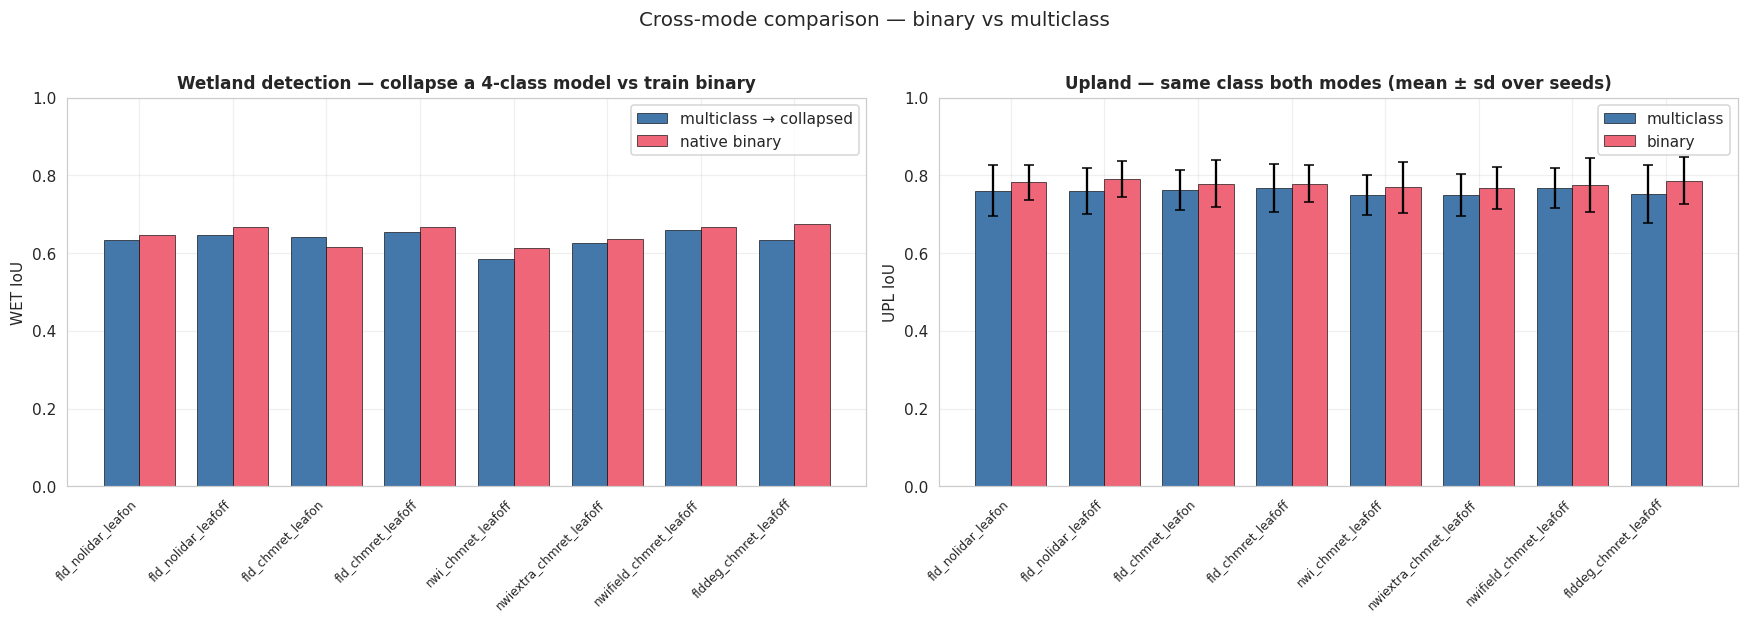

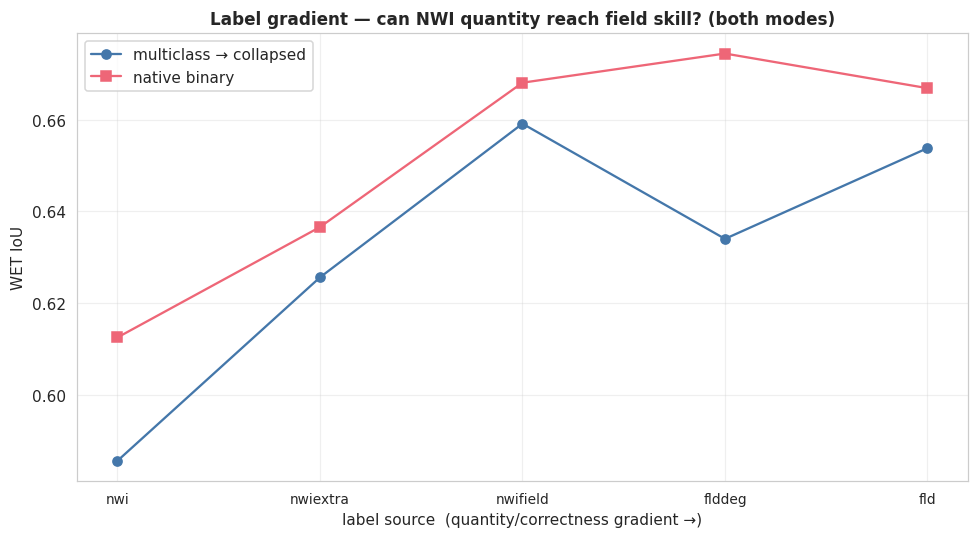

In [30]:
# --- Cross-mode figures: WET (collapsed-mc vs binary), UPL, and label gradient --
if xmode.empty:
    print("No cross-mode table (aggregate both modes first) — skipping section 9 figures.")
else:
    cfgs = list(xmode.index)
    x = np.arange(len(cfgs)); w = 0.38

    fig, (axW, axU) = plt.subplots(1, 2, figsize=(16, 5.5))
    # WET IoU: multiclass-collapsed vs native binary (point estimates from mean CM).
    axW.bar(x - w/2, xmode["WET_iou_mc_collapsed"], w, color="#4477aa",
            edgecolor="black", linewidth=0.4, label="multiclass → collapsed")
    axW.bar(x + w/2, xmode["WET_iou_binary"], w, color="#ee6677",
            edgecolor="black", linewidth=0.4, label="native binary")
    axW.set_xticks(x); axW.set_xticklabels(cfgs, rotation=45, ha="right", fontsize=8)
    axW.set_ylabel("WET IoU"); axW.set_ylim(0, 1.0)
    axW.set_title("Wetland detection — collapse a 4-class model vs train binary")
    axW.legend()
    # UPL IoU: identical class in both modes, so show mean ± sd over seeds.
    axU.bar(x - w/2, xmode["UPL_iou_mc"], w, yerr=xmode["UPL_iou_mc_sd"].fillna(0),
            capsize=3, color="#4477aa", edgecolor="black", linewidth=0.4, label="multiclass")
    axU.bar(x + w/2, xmode["UPL_iou_binary"], w, yerr=xmode["UPL_iou_binary_sd"].fillna(0),
            capsize=3, color="#ee6677", edgecolor="black", linewidth=0.4, label="binary")
    axU.set_xticks(x); axU.set_xticklabels(cfgs, rotation=45, ha="right", fontsize=8)
    axU.set_ylabel("UPL IoU"); axU.set_ylim(0, 1.0)
    axU.set_title("Upland — same class both modes (mean ± sd over seeds)")
    axU.legend()
    fig.suptitle("Cross-mode comparison — binary vs multiclass", y=1.02, fontsize=13)
    fig.tight_layout(); savefig(fig, "09_cross_mode_wet_upl"); plt.show()

    # Label gradient: quantity-vs-correctness across label sources, both modes.
    GRADIENT = ["nwi_chmret_leafoff", "nwiextra_chmret_leafoff",
                "nwifield_chmret_leafoff", "flddeg_chmret_leafoff", "fld_chmret_leafoff"]
    grad = [c for c in GRADIENT if c in xmode.index]
    if len(grad) >= 2:
        gx = np.arange(len(grad))
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(gx, xmode.loc[grad, "WET_iou_mc_collapsed"], marker="o",
                color="#4477aa", label="multiclass → collapsed")
        ax.plot(gx, xmode.loc[grad, "WET_iou_binary"], marker="s",
                color="#ee6677", label="native binary")
        ax.set_xticks(gx)
        ax.set_xticklabels([c.replace("_chmret_leafoff", "") for c in grad], fontsize=9)
        ax.set_ylabel("WET IoU")
        ax.set_xlabel("label source  (quantity/correctness gradient →)")
        ax.set_title("Label gradient — can NWI quantity reach field skill? (both modes)")
        ax.legend()
        fig.tight_layout(); savefig(fig, "09_cross_mode_label_gradient"); plt.show()
    else:
        print("Label-gradient plot needs ≥2 of", GRADIENT, "— have", grad)
